# Step 4: Predict potency and ADMET properties

This notebook reproduces sections 3 onwards of the original pipeline, reading the
generalized outputs of Steps 1–3 directly. Configured here for **BacillusAnthracis**;
switch to any other target by editing the **Job configuration** cell only.

| Step | File consumed |
|---|---|
| Step 1 | `{target}_MLready.csv` — training set, used for overlap removal |
| Step 2 | `{target}_MACAW_embeddings.csv`, `{target}_MACAW_transformer.joblib`, ART models |
| Step 3 | `{Starter}_generated_compounds.csv` per starter (auto-discovered) |

Sections: 3 ART training performance · 4.1 FDA-approved reference compounds · 4.2 Reference
drugs · 4.3 DORAnet-generated compounds · 4.4 Starter molecules · 4.5 Experimental
data · 4.6 Final potency-ADMET-ADME scoring plots


### Imports

In [3]:
import os, sys, gc, pickle, warnings, glob

import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)

import shutil
import yaml
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt, matplotlib.lines as mlines
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator

import cloudpickle, joblib
from scipy.stats import gaussian_kde

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Descriptors, rdMolDescriptors

from sklearn.model_selection import KFold, GroupKFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed

from admet_ai import ADMETModel
from IPython.display import display

warnings.filterwarnings("ignore")
sys.path.append("../")
import macaw  # noqa: F401
from macaw import MACAW  # noqa: F401
from art.core import RecommendationEngine  # noqa: F401
from art.plot import predictions_vs_observations  # noqa: F401

%run "./../plotting.py"
%config InlineBackend.figure_format = "retina"

matplotlib.rcParams.update({
    "font.family":"serif","font.serif":["Times New Roman"],"mathtext.fontset":"stix",
    "font.size":10,"axes.titlesize":10,"axes.labelsize":10,
    "xtick.labelsize":10,"ytick.labelsize":10,"legend.fontsize":10,"savefig.dpi":600,
})
tnr = FontProperties(family="serif", style="normal", size=10)

def canonicalizeSmiles(smi):
    if pd.isna(smi): return None
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

## Job configuration

In [4]:
def findProjectRoot(startDir=None, marker="Input_Data"):
    current = os.path.abspath(startDir or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(current, marker)): return current
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError(f"No project root with '{marker}' above {os.getcwd()}")
        current = parent

projectRoot = findProjectRoot()

# --- TARGET SWITCH: change this string to "Ebola" to run the antiviral version ---
target     = "BacillusAnthracis"
dataDir    = os.path.join(projectRoot, "Input_Data")
resultsDir = os.path.join(projectRoot, target, f"Results_{target}")
os.makedirs(resultsDir, exist_ok=True)

macawTransformerPath = os.path.join(resultsDir, f"{target}_MACAW_transformer.joblib")
macawEmbeddingsFile  = os.path.join(resultsDir, f"{target}_MACAW_embeddings.csv")
mlReadyFile          = os.path.join(resultsDir, f"{target}_MLready.csv")

artModelPaths = {
    "MACAW":     os.path.join(resultsDir, "Step2B_BuildModel_wART", "ART_MACAW",          "ART_results", "art.cpkl"),
    "MoLFormer": os.path.join(resultsDir, "Step2B_BuildModel_wART", "ART_MolFormer",       "ART_results", "art.cpkl"),
    "MIST":      os.path.join(resultsDir, "Step2B_BuildModel_wART", "ART_MIST",            "ART_results", "art.cpkl"),
    "ChemBERTa": os.path.join(resultsDir, "Step2B_BuildModel_wART", "ART_ChemBERTa_wPCA",  "ART_results", "art.cpkl"),
}

drugBankDir = os.path.join(dataDir, "Toxicity", "DrugBank")

# DECISION: populate this file with FDA-approved antibacterials and their ADMET
# annotations using the same schema as the antiviral equivalent:
# required columns -> smiles, ATC_code, Drug_Type
# Analogous Ebola file: drugBankDrug_FDAapproved_antiviral_wToxicity.csv
drugBankFDAFile = os.path.join(
    projectRoot, "Input_Data",
    "drugBankDrug_FDAapproved_antibiotic_wToxicity.csv"
)

# Reference antibiotics withheld from training (Step 1 exclusion set).
# These are evaluated independently in Sections 4.2 and 4.5.
ReferenceDrugs = {
    "Basidalin":           r"C1=C(/C(=C\C=O)/OC1=O)N",
    "Basidalin_Precursor": "CCC=C1OC(=O)[C@@H](C)[C@H]1O",
    "Gatifloxacin":        "CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)C4CC4)F",
    "Ciprofloxacin":       "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Doxycycline":         "C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@@H]3[C@@H](O)[C@@H]21",
    "Levofloxacin":        "C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23",
    "Penicillin G":        "CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O",
}

# DORAnet biosynthesis starters for this target (Step 3A).
# Basidalin_Precursor here is the canonical scaffold representative;
# the many per-starter doranet runs are auto-discovered from
# {resultsDir}/*_generated_compounds.csv in Section 4.3.
StarterMoleculesDict = {
    "Basidalin":           r"C1=C(/C(=C\C=O)/OC1=O)N",
    "Basidalin_Precursor": "CCC=C1OC(=O)[C@@H](C)[C@H]1O",
}

# DECISION: populate with verified experimental pMIC or pIC50 values for
# B. anthracis reference antibiotics retrieved from ChEMBL or your in-house
# assay data. Format mirrors the Ebola version:
#   {"drugName": {"smiles": "<SMILES>", "pPotencyValues": [val1, val2, ...]}}
# Placeholder values below are approximate literature pMIC50 estimates from
# published CLSI/CDC susceptibility tables (replace before submission).
ExperimentalPotencyDict = {
    "Ciprofloxacin": {
        "smiles":         "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
        "pPotencyValues": [6.74, 7.04, 6.44],  # DECISION: replace with ChEMBL assay values
    },
    "Doxycycline": {
        "smiles":         "C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@@H]3[C@@H](O)[C@@H]21",
        "pPotencyValues": [6.57, 6.87, 6.27],  # DECISION: replace with ChEMBL assay values
    },
}

# Color assignments for starters and reference drugs. Additional starters
# discovered from *_generated_compounds.csv are auto-assigned tab10 colors.
baseColorMap = {
    "Basidalin":           "#984EA3",
    "Basidalin_Precursor": "#377EB8",
    "Gatifloxacin":        "#4DAF4A",
    "Ciprofloxacin":       "#E41A1C",
    "Doxycycline":         "#FF7F00",
    "Levofloxacin":        "#A65628",
    "Penicillin G":        "#F781BF",
}

coreToxicityCols  = ["AMES", "hERG", "DILI", "ClinTox", "Carcinogens_Lagunin", "Skin_Reaction", "LD50_Zhu"]
mechanisticAlertCols = [
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
    "NR-AR-LBD", "NR-AR", "NR-AhR", "NR-Aromatase", "NR-ER-LBD", "NR-ER", "NR-PPAR-gamma",
]
admeLiabilityCols = [
    "BBB_Martins", "Pgp_Broccatelli", "Caco2_Wang", "HIA_Hou", "PAMPA_NCATS",
    "Bioavailability_Ma", "CYP1A2_Veith", "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels", "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels", "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels", "CYP3A4_Veith",
]
potencyCols = [
    "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction",  "IC50(M)_lower_95CI",  "IC50(M)_upper_95CI",
]
topN      = 20
paramGrid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}
nSplits   = 10

print("Target:", target, "| resultsDir:", resultsDir)
for lbl, p in [
    ("MACAW embeddings",  macawEmbeddingsFile),
    ("MACAW transformer", macawTransformerPath),
    ("MLready",           mlReadyFile),
    ("ART MACAW",         artModelPaths["MACAW"]),
    ("DrugBank FDA",      drugBankFDAFile),
]:
    print(f"  {lbl}: {'found' if os.path.exists(p) else 'MISSING'} -> {os.path.basename(p)}")


Target: BacillusAnthracis | resultsDir: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis
  MACAW embeddings: found -> BacillusAnthracis_MACAW_embeddings.csv
  MACAW transformer: found -> BacillusAnthracis_MACAW_transformer.joblib
  MLready: found -> BacillusAnthracis_MLready.csv
  ART MACAW: MISSING -> art.cpkl
  DrugBank FDA: found -> drugBankDrug_FDAapproved_antibiotic_wToxicity.csv


### Helper functions

In [5]:
def loadTransformer(path):
    try: return joblib.load(path)
    except Exception:
        with open(path,"rb") as h: return pickle.load(h)

def macawEmbed(df, smilesCol, transformer):
    emb  = transformer.transform(df[smilesCol])
    cols = [f"MACAW_{i+1}" for i in range(emb.shape[1])]
    return pd.concat([df, pd.DataFrame(emb, columns=cols, index=df.index)], axis=1)

def artPredict(dfWMacaw, art, idCols):
    macawCols     = [c for c in dfWMacaw.columns if c.startswith("MACAW_")]
    mean, std     = art.post_pred_stats(dfWMacaw[macawCols].values)
    out           = dfWMacaw[[c for c in idCols if c in dfWMacaw.columns]].copy()
    out["pPotency_prediction"]  = mean
    out["pPotency_std"]         = std
    out["pPotency_lower_95CI"]  = mean - 1.96*std
    out["pPotency_upper_95CI"]  = mean + 1.96*std
    out["IC50(M)_prediction"]   = 10**(-mean)
    out["IC50(M)_lower_95CI"]   = 10**(-out["pPotency_upper_95CI"])
    out["IC50(M)_upper_95CI"]   = 10**(-out["pPotency_lower_95CI"])
    return out.sort_values("pPotency_prediction",ascending=False).reset_index(drop=True)

def computeAdmet(df, smilesCol):
    smilesList = df[smilesCol].dropna().astype(str).tolist()
    pred = ADMETModel().predict(smiles=smilesList)
    pred = pred if isinstance(pred,pd.DataFrame) else pd.DataFrame(pred)
    if "Canonical_SMILES" not in pred.columns:
        pred = pred.reset_index().rename(columns={"index":"Canonical_SMILES"})
    return df.merge(pred, on=smilesCol, how="left")

def retainEndpoints(df, idCols, withPotency=True):
    keep  = [c for c in idCols if c in df.columns]
    if withPotency: keep += [c for c in potencyCols if c in df.columns]
    keep += [c for c in coreToxicityCols+mechanisticAlertCols+admeLiabilityCols if c in df.columns]
    return df[keep].copy()

def removeOverlap(df, smilesCol, trainSet, label=""):
    before  = len(df)
    overlap = set(df[smilesCol].dropna().astype(str)) & trainSet
    out     = df[~df[smilesCol].isin(trainSet)].reset_index(drop=True)
    print(f"{label} overlap removed: {len(overlap):,} | remaining: {len(out):,}")
    return out

def showRange(df, label=""):
    vMin = df.loc[df["pPotency_prediction"].idxmin()]
    vMax = df.loc[df["pPotency_prediction"].idxmax()]
    print(f"{label} pPotency {vMin['pPotency_prediction']:.2f}±{vMin['pPotency_std']:.2f} – "
          f"{vMax['pPotency_prediction']:.2f}±{vMax['pPotency_std']:.2f}")

## 3. ART training performance

In [6]:
trainingData_wMACAW = pd.read_csv(macawEmbeddingsFile)
trainingData        = pd.read_csv(mlReadyFile)
macawInputCols      = [c for c in trainingData_wMACAW.columns if c.startswith("MACAW_")]
trainingSmilesSet   = set(trainingData["Canonical_SMILES"].dropna().astype(str))
macawTransformer    = loadTransformer(macawTransformerPath)
print(f"MACAW embeddings: {len(macawInputCols)}")
print(f"Training rows (with duplicates): {len(trainingData):,} | Unique SMILES: {len(trainingSmilesSet):,}")

MACAW embeddings: 90
Training rows (with duplicates): 3,973 | Unique SMILES: 1,644


ART MACAW loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/Step2B_BuildModel_wART/ART_MACAW/ART_results/art.cpkl


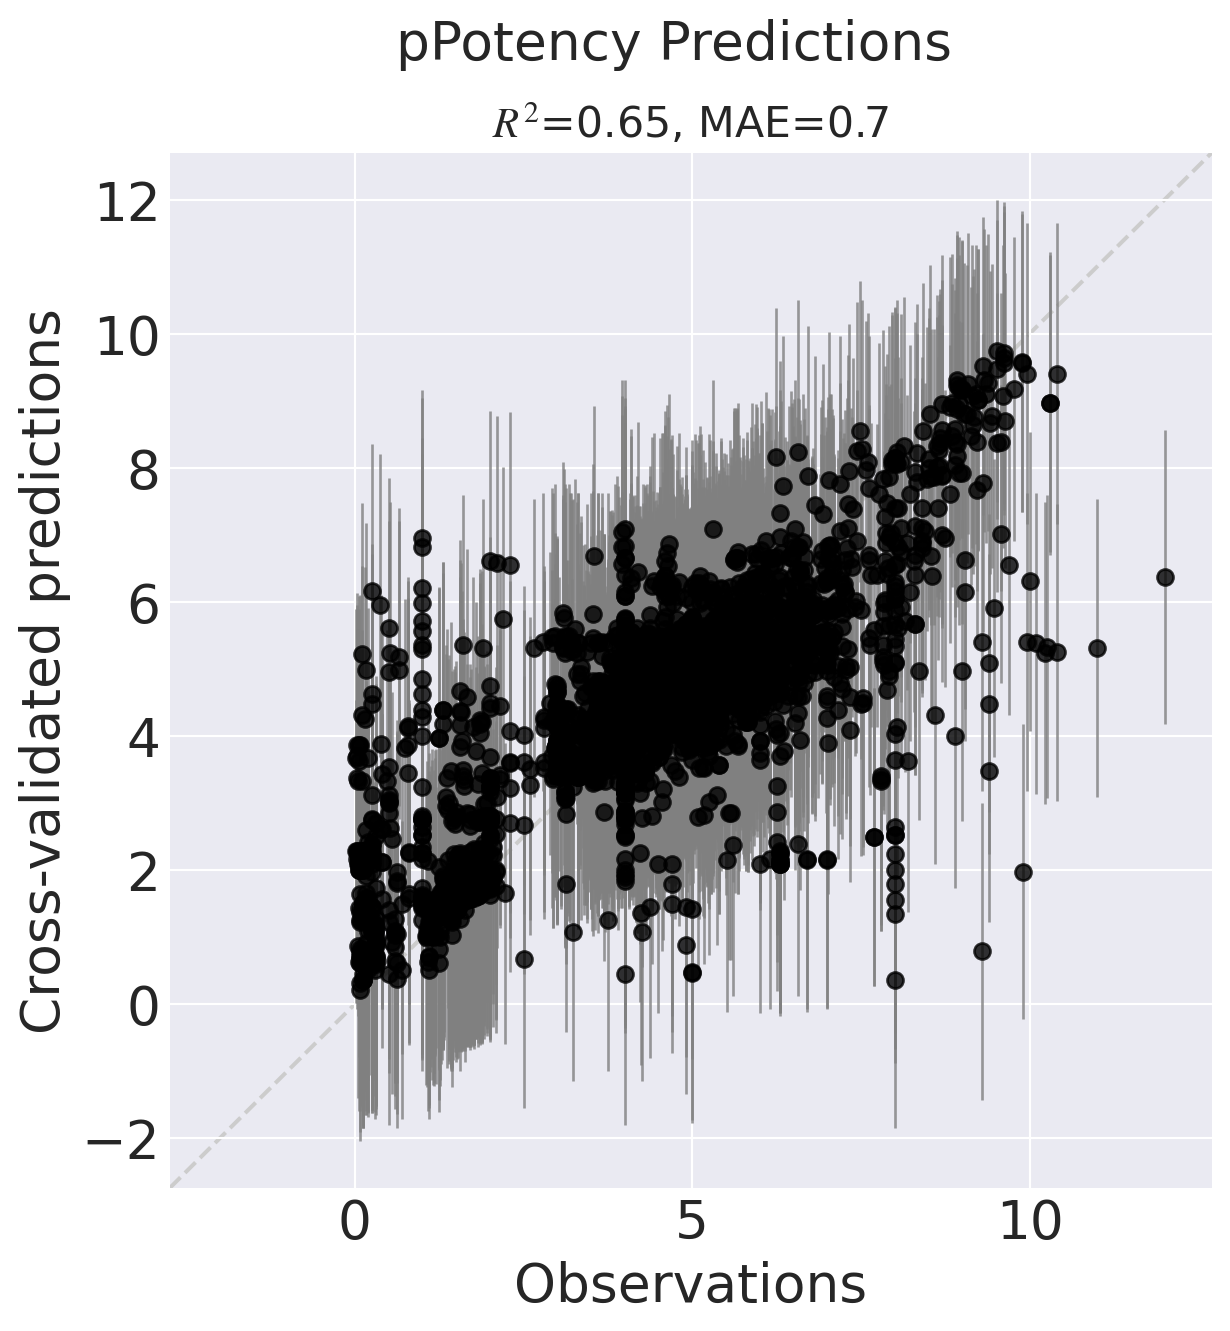

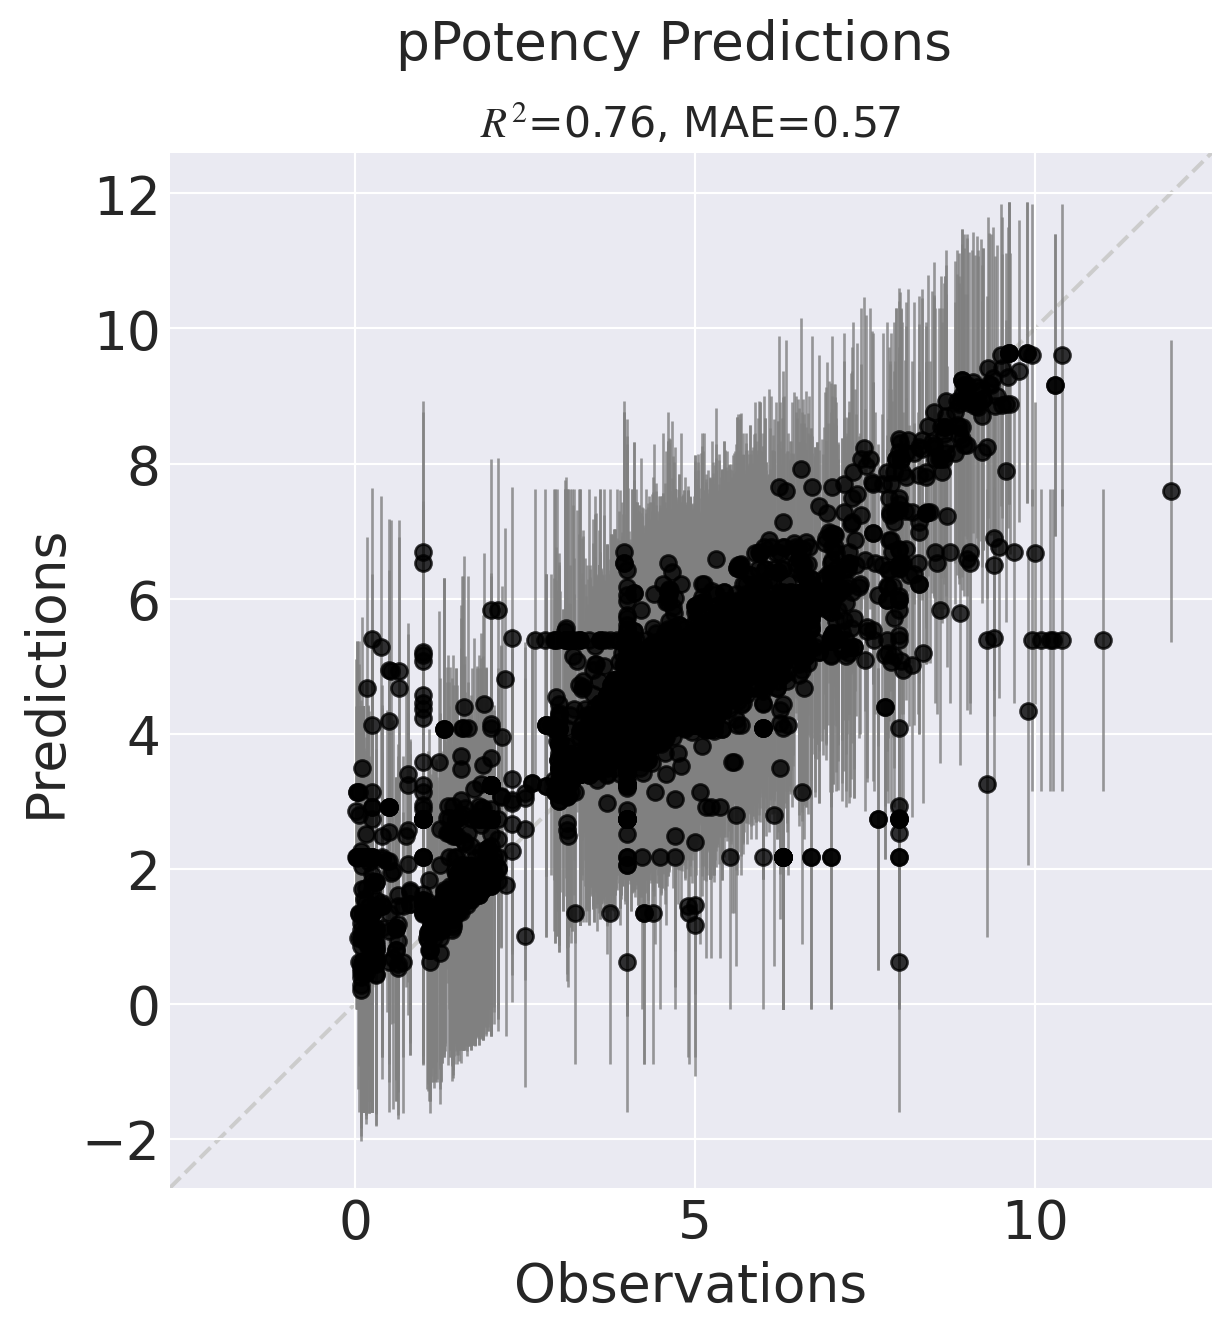

In [8]:
with open(artModelPaths["MACAW"],"rb") as h: art_macaw = cloudpickle.load(h)
art_macaw.output_dir = resultsDir; os.makedirs(resultsDir, exist_ok=True)
print(f"ART MACAW loaded from: {artModelPaths['MACAW']}")
predictions_vs_observations(art_macaw, cv=True,  error_bars=True)
predictions_vs_observations(art_macaw, cv=False, error_bars=True)

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_ART_MACAW_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_ART_MACAW_CV.png


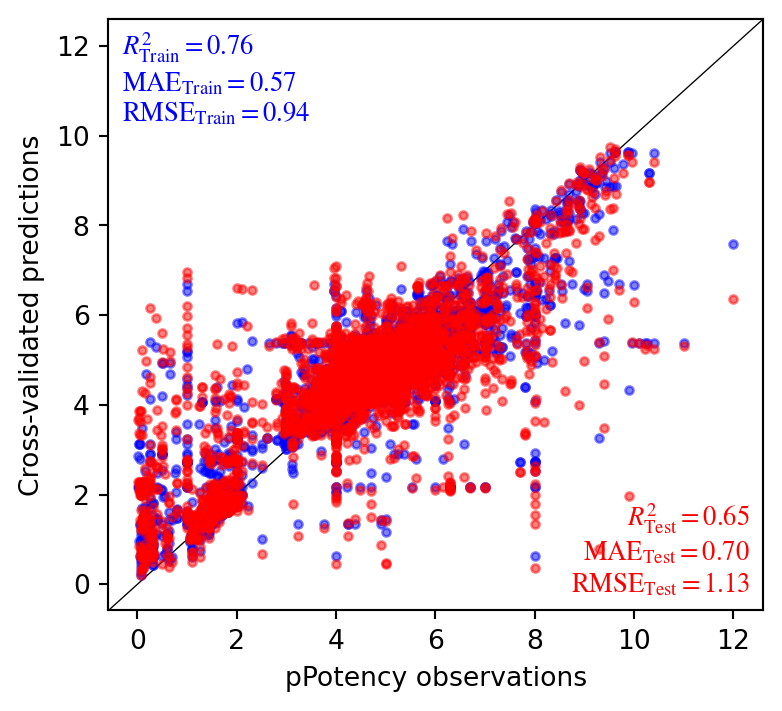

Saved parity plot for MACAW
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_ART_MoLFormer_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_ART_MoLFormer_CV.png


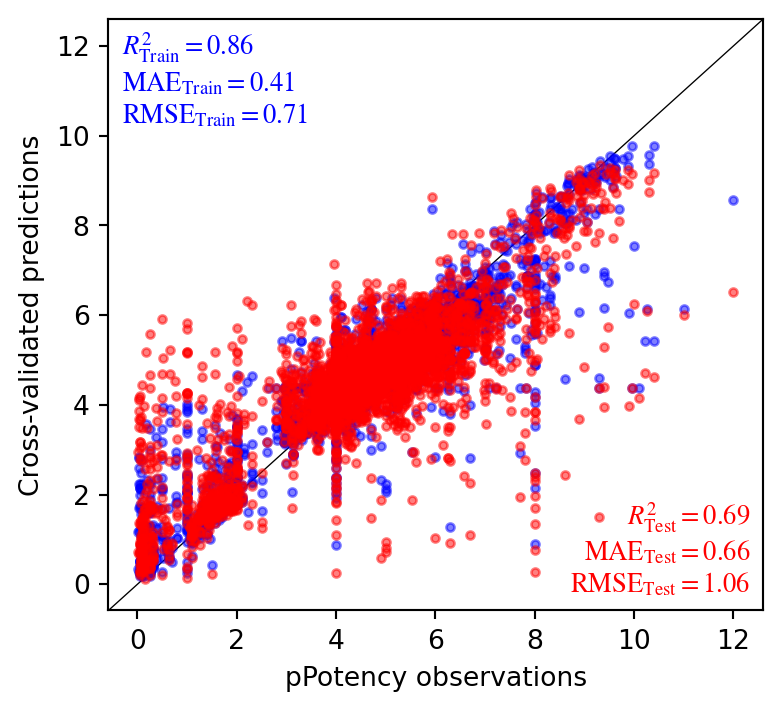

Saved parity plot for MoLFormer
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_ART_MIST_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_ART_MIST_CV.png


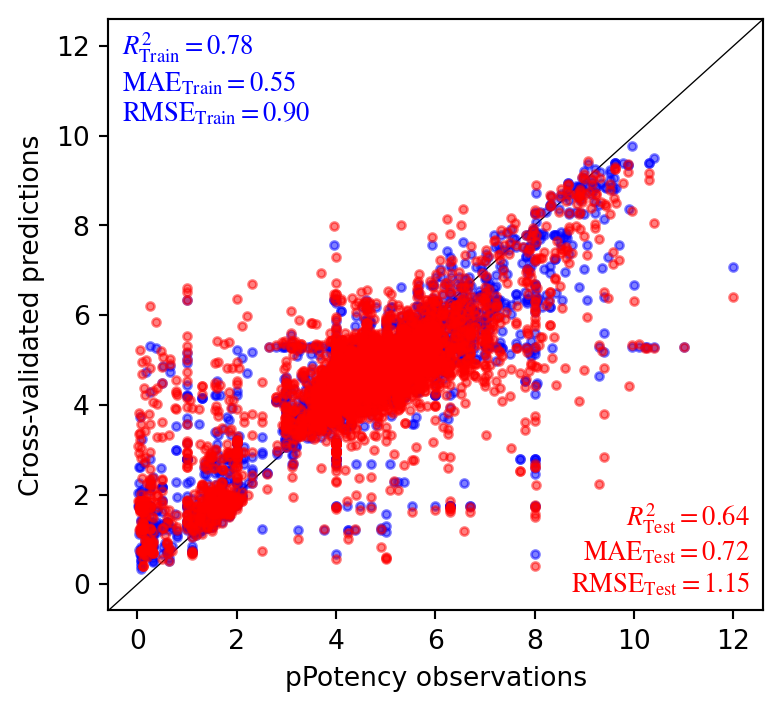

Saved parity plot for MIST
[skip] ChemBERTa: not found


In [9]:
for embLabel, modelPath in artModelPaths.items():
    if not os.path.isfile(modelPath):
        print(f"[skip] {embLabel}: not found"); continue
    with open(modelPath,"rb") as h: artModel = cloudpickle.load(h)
    artModel.output_dir = resultsDir
    respVar    = artModel.response_vars[0]
    xTr        = artModel.df["Input Variables"][artModel.input_vars].values
    yObs       = artModel.df["Response Variables"][respVar].values
    yPredMean, _ = artModel.post_pred_stats(xTr)
    yPred      = yPredMean[:,0]
    cvDf       = artModel.model_prediction_cv_dfs[0]
    yPredCv    = np.array(cvDf.loc["Ensemble Model (L1)","Predictions"])
    parity_plot(x=yObs, y=yPred, x_test=yObs.copy(), y_test=yPredCv,
        xlabel="pPotency observations", ylabel="Cross-validated predictions",
        savetitle=os.path.join(resultsDir, f"{target}_ART_{embLabel}_CV.svg"),
        save_formats=["svg","png"])
    print(f"Saved parity plot for {embLabel}")

## 4.1 FDA-approved antibacterials (DrugBank)

Reads the DrugBank FDA-approved antibacterial table and scores all compounds
with ART + ADMET-AI. This cohort serves as the reference distribution for the
desirability calibration in Section 4.6. The file must have columns:
`smiles`, `ATC_code`, `Drug_Type` — the same schema as the antiviral equivalent.


In [10]:
fdaAntiviralDF = pd.read_csv(drugBankFDAFile, dtype=str)
fdaAntiviralDF = fdaAntiviralDF[["smiles","ATC_code","Drug_Type"]].copy()
fdaAntiviralDF["Canonical_SMILES"] = fdaAntiviralDF["smiles"].apply(canonicalizeSmiles)
fdaAntiviralDF = fdaAntiviralDF.drop(columns=["smiles"])
fdaAntiviralDF = removeOverlap(fdaAntiviralDF,"Canonical_SMILES",trainingSmilesSet,"FDA antivirals:")
fdaAntiviralDF

FDA antivirals: overlap removed: 19 | remaining: 135


,ATC_code,Drug_Type,Canonical_SMILES
0,J01GB;J01RA,antibiotic,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...
1,J01CA;J01CR,antibiotic,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...
2,J01CA;J01CR,antibiotic,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...
3,J01DF,antibiotic,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...
4,J01CA;J01CR,antibiotic,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...
...,...,...,...
130,J01AA,antibiotic,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...
131,J01RA;J01XD,antibiotic,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C
132,J01FA,antibiotic,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...
133,J01MA,antibiotic,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...


In [11]:
fdaAntiviralDF_wMACAW = macawEmbed(fdaAntiviralDF,"Canonical_SMILES",macawTransformer)
fdaAntiviralDF_wMACAW.to_csv(os.path.join(resultsDir,"fdaAntiviralDF_wMACAW.csv"),index=False)
fdaAntiviralDF_wART = artPredict(fdaAntiviralDF_wMACAW, art_macaw, ["Canonical_SMILES","Drug_Type"])
fdaAntiviralDF_wART.to_csv(os.path.join(resultsDir,"fdaAntiviralDF_wART.csv"),index=False)
showRange(fdaAntiviralDF_wART,"FDA antivirals:")
fdaAntiviralDF_wART

[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:30] DEPRECATION W

FDA antivirals: pPotency 3.31±1.14 – 5.39±1.14


,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,antibiotic,5.385019,1.140731,3.149186,7.620851,0.000004,2.394138e-08,0.000709
1,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,antibiotic,5.385019,1.140731,3.149186,7.620851,0.000004,2.394138e-08,0.000709
2,CO/N=C1\CN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3C2CC2)...,antibiotic,5.347638,1.143041,3.107277,7.587998,0.000004,2.582270e-08,0.000781
3,C[C@@H]1CN(c2c(F)c(N)c3c(=O)c(C(=O)O)cn(C4CC4)...,antibiotic,5.339056,1.141604,3.101512,7.576601,0.000005,2.650934e-08,0.000792
4,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCNCC3)nc21,antibiotic,5.316574,1.141858,3.078532,7.554615,0.000005,2.788590e-08,0.000835
...,...,...,...,...,...,...,...,...,...
130,CC(C)(C)C(=O)OCOC(=O)[C@@H]1N2C(=O)[C@@H](NC(=...,antibiotic,3.582013,1.142700,1.342322,5.821704,0.000262,1.507633e-06,0.045465
131,CC=CC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](N)c3...,antibiotic,3.537148,1.149101,1.284909,5.789387,0.000290,1.624102e-06,0.051891
132,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,antibiotic,3.531394,1.146552,1.284152,5.778636,0.000294,1.664807e-06,0.051981
133,CC(Oc1ccccc1)C(=O)N[C@@H]1C(=O)N2[C@@H]1SC(C)(...,antibiotic,3.354344,1.143980,1.112142,5.596545,0.000442,2.531949e-06,0.077243


In [12]:
fdaAntiviralDF_wART_wADMET = computeAdmet(fdaAntiviralDF_wART,"Canonical_SMILES")
fdaAntiviralDF_wART_wADMET = retainEndpoints(fdaAntiviralDF_wART_wADMET,["Canonical_SMILES","Drug_Type"])
fdaAntiviralDF_wART_wADMET.to_csv(os.path.join(resultsDir,"fdaAntiviralDF_wART_wADMET.csv"),index=False)
print("FDA antiviral final shape:", fdaAntiviralDF_wART_wADMET.shape)
fdaAntiviralDF_wART_wADMET.head()

model ensembles:   0%|                                                                                               | 0/2 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Output()

Output()

Output()

...

Output()

Output()

model ensembles: 100%|███████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.72s/it]


FDA antiviral final shape: (135, 42)


,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,antibiotic,5.385019,1.140731,3.149186,7.620851,0.000004,2.394138e-08,0.000709,0.547343,...,0.217382,0.924102,0.025488,0.018547,0.093260,0.011856,0.057289,0.028817,0.220573,0.002847
1,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,antibiotic,5.385019,1.140731,3.149186,7.620851,0.000004,2.394138e-08,0.000709,0.607500,...,0.190829,0.915131,0.021558,0.014616,0.074688,0.009346,0.055359,0.029954,0.213833,0.002800
2,CO/N=C1\CN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3C2CC2)...,antibiotic,5.347638,1.143041,3.107277,7.587998,0.000004,2.582270e-08,0.000781,0.837125,...,0.146398,0.850916,0.016434,0.012527,0.087234,0.010366,0.039728,0.024557,0.256285,0.007869
3,C[C@@H]1CN(c2c(F)c(N)c3c(=O)c(C(=O)O)cn(C4CC4)...,antibiotic,5.339056,1.141604,3.101512,7.576601,0.000005,2.650934e-08,0.000792,0.774220,...,0.115307,0.811317,0.017211,0.026063,0.055716,0.026706,0.042988,0.038653,0.266434,0.028308
4,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCNCC3)nc21,antibiotic,5.316574,1.141858,3.078532,7.554615,0.000005,2.788590e-08,0.000835,0.659039,...,0.110004,0.888913,0.023637,0.007362,0.075838,0.005990,0.036184,0.017483,0.133304,0.001795


### Withdrawn / legacy antibacterials — ADMET only

DECISION: if a DrugBank withdrawn-antibacterials table is available, convert
the cell below from raw to code and update the file path.


## 4.2 Reference drugs

In [13]:
referenceDrugsDF = pd.DataFrame([{"drugName":k,"Canonical_SMILES":canonicalizeSmiles(v)}
                                    for k,v in ReferenceDrugs.items()])
referenceDrugsDF = removeOverlap(referenceDrugsDF,"Canonical_SMILES",trainingSmilesSet,"Reference drugs:")
referenceDrugsDF

Reference drugs: overlap removed: 0 | remaining: 7


,drugName,Canonical_SMILES
0,Basidalin,NC1=CC(=O)O/C1=C/C=O
1,Basidalin_Precursor,CCC=C1OC(=O)[C@@H](C)[C@H]1O
2,Gatifloxacin,COc1c(N2CCNC(C)C2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC...
3,Ciprofloxacin,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O
4,Doxycycline,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...
5,Levofloxacin,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...
6,Penicillin G,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...


In [14]:
referenceDrugsDF_wMACAW       = macawEmbed(referenceDrugsDF,"Canonical_SMILES",macawTransformer)
referenceDrugsDF_ARTprediction = artPredict(referenceDrugsDF_wMACAW,art_macaw,["Canonical_SMILES","drugName"])
referenceDrugsDF_ARTprediction.to_csv(os.path.join(resultsDir,"referenceDrugsDF_ARTprediction.csv"),index=False)
referenceDrugsDF_ARTprediction[["Canonical_SMILES"]].to_csv(
    os.path.join(resultsDir,"referenceDrugsDF_ARTprediction_SMILES.csv"),index=False)
showRange(referenceDrugsDF_ARTprediction,"Reference drugs:")
referenceDrugsDF_ARTprediction

[13:56:40] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:40] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:40] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:40] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:40] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:40] DEPRECATION WARNING: please use AtomPairGenerator
[13:56:40] DEPRECATION WARNING: please use AtomPairGenerator


Reference drugs: pPotency 3.61±1.14 – 5.39±1.14


,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,Levofloxacin,5.385019,1.140731,3.149186,7.620851,0.000004,2.394138e-08,0.000709
1,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,Ciprofloxacin,5.292257,1.140469,3.056937,7.527576,0.000005,2.967726e-08,0.000877
2,COc1c(N2CCNC(C)C2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC...,Gatifloxacin,5.276057,1.141170,3.039363,7.512751,0.000005,3.070781e-08,0.000913
3,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,Doxycycline,5.054335,1.148763,2.802759,7.305910,0.000009,4.944128e-08,0.001575
4,NC1=CC(=O)O/C1=C/C=O,Basidalin,3.830545,1.139943,1.596257,6.064834,0.000148,8.613234e-07,0.025336
5,CCC=C1OC(=O)[C@@H](C)[C@H]1O,Basidalin_Precursor,3.701485,1.139834,1.467410,5.935559,0.000199,1.159955e-06,0.034087
6,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,Penicillin G,3.610017,1.140807,1.374035,5.845999,0.000245,1.425611e-06,0.042263


Sampling: [y]


Molecule 1: mean=5.37 std=1.16 95%CI=[3.08,7.59] IC50=4.3138µM


Sampling: [y]
Sampling: [y]


Molecule 2: mean=5.31 std=1.15 95%CI=[3.08,7.54] IC50=4.9300µM
Molecule 3: mean=5.25 std=1.14 95%CI=[3.01,7.46] IC50=5.5816µM


Sampling: [y]


Molecule 4: mean=5.08 std=1.15 95%CI=[2.90,7.33] IC50=8.2971µM


Sampling: [y]
Sampling: [y]


Molecule 5: mean=3.84 std=1.13 95%CI=[1.64,6.06] IC50=143.8217µM
Molecule 6: mean=3.72 std=1.12 95%CI=[1.59,5.91] IC50=189.6418µM


Sampling: [y]


Molecule 7: mean=3.59 std=1.14 95%CI=[1.37,5.82] IC50=254.2883µM


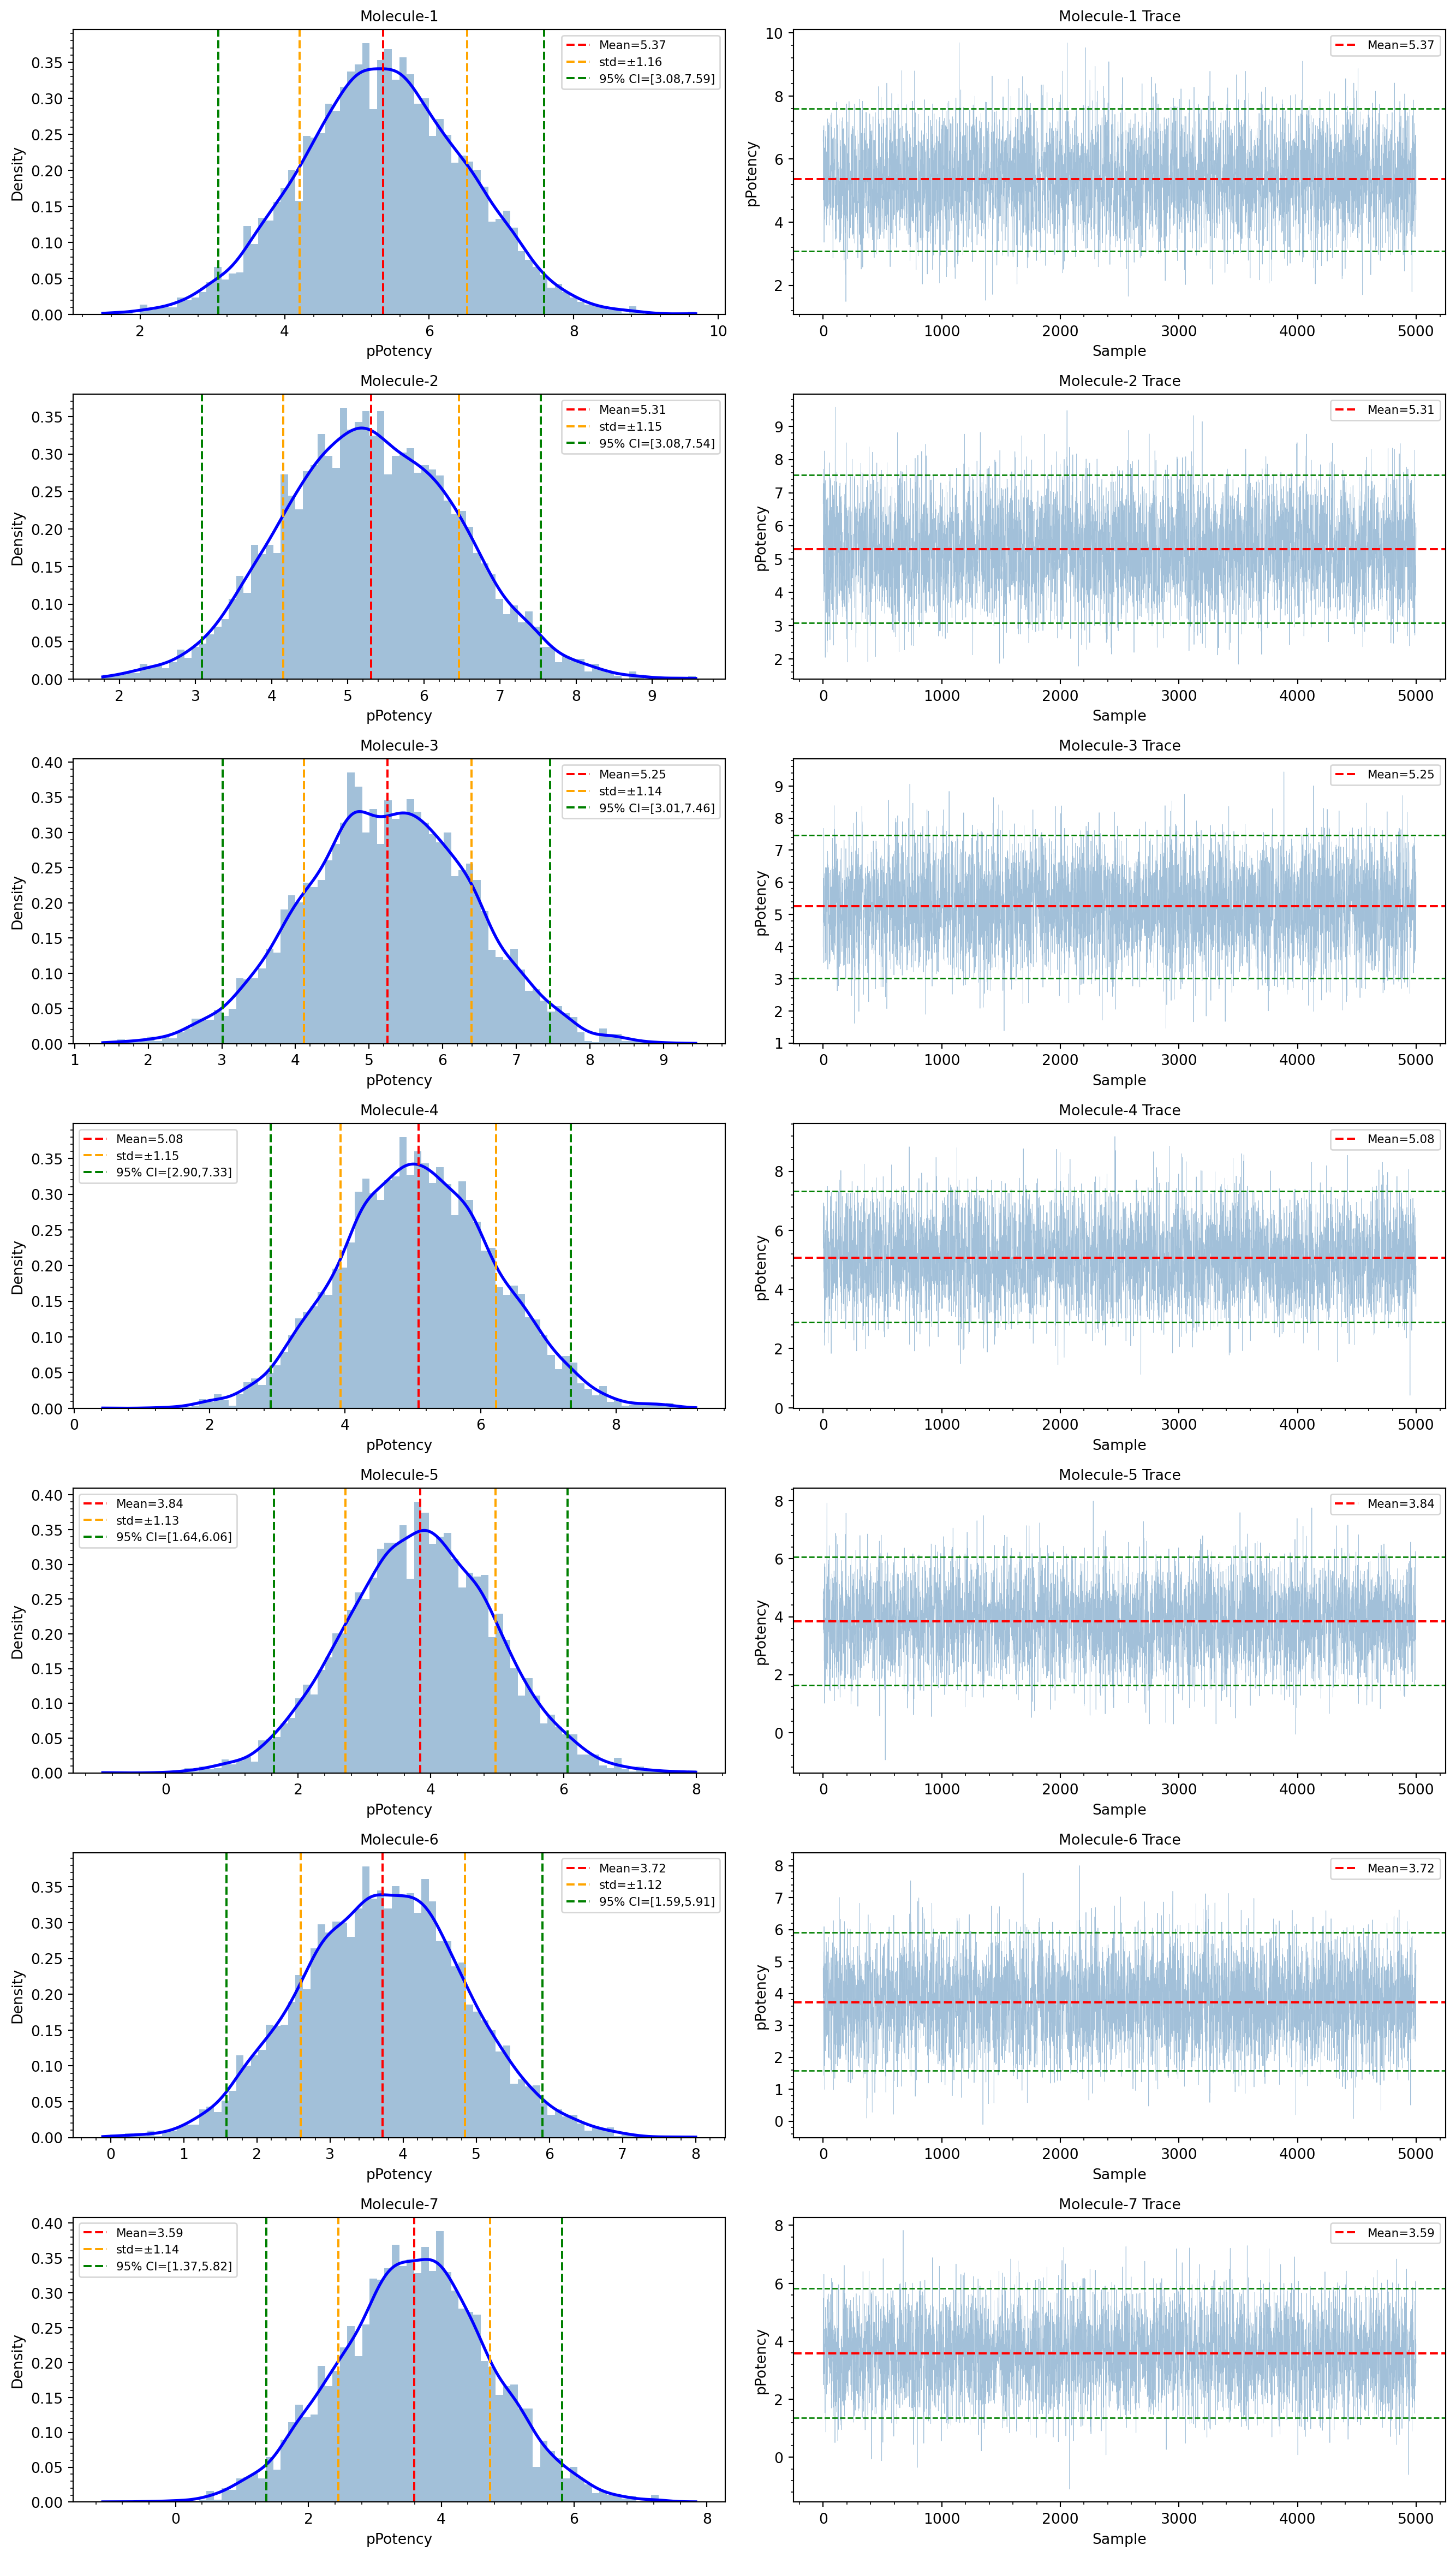

In [15]:
def plotPotencyFromDraws(predDf, featDf, art, n=5, nSamples=5000, savePrefix=""):
    macawCols = [c for c in featDf.columns if c.startswith("MACAW_")]
    merged = (predDf.nlargest(n,"pPotency_prediction")
                     .merge(featDf[["Canonical_SMILES",*macawCols]],on="Canonical_SMILES",how="inner"))
    if merged.empty: print("No molecules to plot."); return
    fig, axes = plt.subplots(len(merged),2,figsize=(14,3.5*len(merged)),squeeze=False)
    for i,(_,row) in enumerate(merged.iterrows()):
        x     = row[macawCols].to_numpy(dtype=float).reshape(1,-1)
        draws = np.asarray(art.post_pred_draws(x,n_samples=nSamples)).ravel()
        if draws.size < 2: continue
        mu,sg = draws.mean(), draws.std()
        lo,hi = np.percentile(draws,[2.5,97.5])
        ax0   = axes[i,0]
        ax0.hist(draws,bins=min(80,max(1,len(draws)//2)),density=True,alpha=0.5,color="steelblue")
        try:
            kde=gaussian_kde(draws); xr=np.linspace(draws.min(),draws.max(),500)
            ax0.plot(xr,kde(xr),"b-",lw=2)
        except Exception: pass
        ax0.axvline(mu,color="red",linestyle="--",label=f"Mean={mu:.2f}")
        ax0.axvline(mu-sg,color="orange",linestyle="--",lw=1.5)
        ax0.axvline(mu+sg,color="orange",linestyle="--",lw=1.5,label=f"std=±{sg:.2f}")
        ax0.axvline(lo,color="green",linestyle="--",label=f"95% CI=[{lo:.2f},{hi:.2f}]")
        ax0.axvline(hi,color="green",linestyle="--")
        ax0.set_xlabel("pPotency"); ax0.set_ylabel("Density"); ax0.legend(fontsize=8)
        ax0.set_title(f"Molecule-{i+1}")
        ax0.xaxis.set_minor_locator(AutoMinorLocator(5)); ax0.yaxis.set_minor_locator(AutoMinorLocator(5))
        ax1 = axes[i,1]
        ax1.plot(draws,alpha=0.5,lw=0.3,color="steelblue")
        ax1.axhline(mu,color="red",linestyle="--",lw=1.5,label=f"Mean={mu:.2f}")
        ax1.axhline(lo,color="green",linestyle="--",lw=1)
        ax1.axhline(hi,color="green",linestyle="--",lw=1)
        ax1.set_xlabel("Sample"); ax1.set_ylabel("pPotency"); ax1.legend(fontsize=8)
        ax1.set_title(f"Molecule-{i+1} Trace")
        ax1.xaxis.set_minor_locator(AutoMinorLocator(5)); ax1.yaxis.set_minor_locator(AutoMinorLocator(5))
        print(f"Molecule {i+1}: mean={mu:.2f} std={sg:.2f} 95%CI=[{lo:.2f},{hi:.2f}] IC50={10**(-mu)*1e6:.4f}µM")
    plt.tight_layout()
    if savePrefix:
        plt.savefig(os.path.join(resultsDir,f"{savePrefix}_ARTprobability.png"),dpi=300,bbox_inches="tight")
    plt.show()

plotPotencyFromDraws(referenceDrugsDF_ARTprediction, referenceDrugsDF_wMACAW,
                     art_macaw, n=len(referenceDrugsDF_ARTprediction), savePrefix="referenceDrugs")

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/referenceDrugsDF_wARTprediction_grid.png


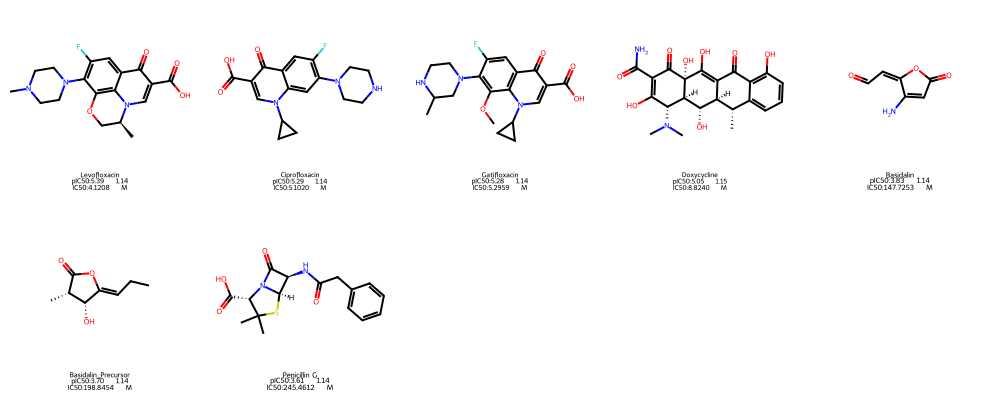

In [16]:
df = referenceDrugsDF_ARTprediction.copy()
p_arr   = df["pPotency_prediction"].values
std_arr = df["pPotency_std"].values if "pPotency_std" in df.columns else np.full(len(df),np.nan)
ic50_arr= 10**(-p_arr)*1e6; drug_arr=df["drugName"].values; smi_arr=df["Canonical_SMILES"].values

mols,legs=[],[]
for smi,drug,pp,ic,ss in zip(smi_arr,drug_arr,p_arr,ic50_arr,std_arr):
    mol=Chem.MolFromSmiles(smi)
    if mol is None: continue
    label=(f"{drug}\npIC50:{pp:.2f}±{ss:.2f}\nIC50:{ic:.4f}µM" if pd.notna(ss)
           else f"{drug}\npIC50:{pp:.2f}\nIC50:{ic:.4f}µM")
    mols.append(mol); legs.append(label)

outPng=os.path.join(resultsDir,"referenceDrugsDF_wARTprediction_grid.png")
outSvg=os.path.join(resultsDir,"referenceDrugsDF_wARTprediction_grid.svg")
png=Draw.MolsToGridImage(mols,subImgSize=(200,200),molsPerRow=5,legends=legs,useSVG=False,returnPNG=True)
svg=Draw.MolsToGridImage(mols,subImgSize=(200,200),molsPerRow=5,legends=legs,useSVG=True)
with open(outPng,"wb") as fh: fh.write(png.data if hasattr(png,"data") else png)
with open(outSvg,"w")  as fh: fh.write(svg.data if hasattr(svg,"data") else svg)
print("Saved:",outPng); display(png)

In [17]:
referenceDrugsDF_wART_wADMET = computeAdmet(referenceDrugsDF_ARTprediction,"Canonical_SMILES")
referenceDrugsDF_wART_wADMET = retainEndpoints(referenceDrugsDF_wART_wADMET,["Canonical_SMILES","drugName"])
referenceDrugsDF_wART_wADMET.to_csv(os.path.join(resultsDir,"referenceDrugsDF_wART_wADMET.csv"),index=False)
referenceDrugsDF_wART_wADMET

model ensembles:   0%|                                                                                               | 0/2 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

model ensembles: 100%|███████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.84it/s]


,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,Levofloxacin,5.385019,1.140731,3.149186,7.620851,0.000004,2.394138e-08,0.000709,0.607500,...,0.190829,0.915131,0.021558,0.014616,0.074688,0.009346,0.055359,0.029954,0.213833,0.002800
1,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,Ciprofloxacin,5.292257,1.140469,3.056937,7.527576,0.000005,2.967726e-08,0.000877,0.533075,...,0.075984,0.846796,0.015063,0.012601,0.073429,0.009488,0.033706,0.025682,0.129952,0.002588
2,COc1c(N2CCNC(C)C2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC...,Gatifloxacin,5.276057,1.141170,3.039363,7.512751,0.000005,3.070781e-08,0.000913,0.424405,...,0.105891,0.885625,0.007676,0.015496,0.083823,0.011969,0.035773,0.022529,0.181295,0.005947
3,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,Doxycycline,5.054335,1.148763,2.802759,7.305910,0.000009,4.944128e-08,0.001575,0.331862,...,0.058068,0.868440,0.003596,0.008808,0.038878,0.006831,0.009851,0.002821,0.217391,0.003589
4,NC1=CC(=O)O/C1=C/C=O,Basidalin,3.830545,1.139943,1.596257,6.064834,0.000148,8.613234e-07,0.025336,0.836058,...,0.900207,0.801551,0.673103,0.094615,0.152139,0.038608,0.077673,0.007188,0.436956,0.010456
5,CCC=C1OC(=O)[C@@H](C)[C@H]1O,Basidalin_Precursor,3.701485,1.139834,1.467410,5.935559,0.000199,1.159955e-06,0.034087,0.141290,...,0.939418,0.937102,0.133869,0.044454,0.280110,0.011092,0.193841,0.004460,0.350301,0.002830
6,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,Penicillin G,3.610017,1.140807,1.374035,5.845999,0.000245,1.425611e-06,0.042263,0.069191,...,0.022473,0.822873,0.000484,0.012205,0.132608,0.012019,0.004932,0.002068,0.110813,0.001803


## 4.3 DORAnet-generated compounds

In [20]:
starterFiles = sorted(glob.glob(os.path.join(resultsDir + "/Step3A_Antibiotic_Compounds/Step2_BasidalinPrecursor/*_generated_compounds.csv")))
starterFiles = [f for f in starterFiles if "_highFeasibility" not in f]
print(f"Found {len(starterFiles)} starter files:")

dfList=[]
for filePath in starterFiles:
    starterName = os.path.basename(filePath).replace("_generated_compounds.csv","")
    df = pd.read_csv(filePath,dtype=str); df["Starter_Name"]=starterName
    print(f"  {starterName}: {len(df)} compounds"); dfList.append(df)

generatedCompounds = pd.concat(dfList,ignore_index=True); del dfList; gc.collect()
smiColRaw = "Canonical_SMILES" if "Canonical_SMILES" in generatedCompounds.columns else "Target_Canonical_SMILES"
generatedCompounds = generatedCompounds.rename(columns={smiColRaw:"Canonical_SMILES"})
generatedCompounds = (generatedCompounds.dropna(subset=["Canonical_SMILES"])
    .drop_duplicates(subset="Canonical_SMILES",keep="first")
    .filter(items=["Starter_Name","starter_Canonical_SMILES","Canonical_SMILES"])
    .reset_index(drop=True))
gc.collect()
generatedCompounds.to_csv(os.path.join(resultsDir,f"{target}_allGeneratedCompounds_combined.csv"),index=False)
print(f"Combined after dedup: {len(generatedCompounds)}")
generatedCompounds

Found 1489 starter files:
  BasidalinPrecursor_starter_00000: 882 compounds
  BasidalinPrecursor_starter_00001: 467 compounds
  BasidalinPrecursor_starter_00002: 614 compounds
  BasidalinPrecursor_starter_00003: 1605 compounds
  BasidalinPrecursor_starter_00004: 1641 compounds
  BasidalinPrecursor_starter_00005: 668 compounds
  BasidalinPrecursor_starter_00006: 2366 compounds
  BasidalinPrecursor_starter_00007: 785 compounds
  BasidalinPrecursor_starter_00009: 1641 compounds
  BasidalinPrecursor_starter_00010: 668 compounds
  BasidalinPrecursor_starter_00011: 2366 compounds
  BasidalinPrecursor_starter_00013: 1547 compounds
  BasidalinPrecursor_starter_00014: 708 compounds
  BasidalinPrecursor_starter_00015: 569 compounds
  BasidalinPrecursor_starter_00016: 1535 compounds
  BasidalinPrecursor_starter_00018: 2207 compounds
  BasidalinPrecursor_starter_00021: 467 compounds
  BasidalinPrecursor_starter_00022: 2210 compounds
  BasidalinPrecursor_starter_00023: 1547 compounds
  BasidalinPre

,Starter_Name,starter_Canonical_SMILES,Canonical_SMILES
0,BasidalinPrecursor_starter_00000,CCC=C1OC(=O)[C@@H](C)[C@H]1O,CCC=C(O)C(O)(C(O)=CCC)[C@H](C)C(=O)O
1,BasidalinPrecursor_starter_00000,CCC=C1OC(=O)[C@@H](C)[C@H]1O,CCC=C(O)CCC=C(O)[C@H](O)[C@H](C)C(=O)O
2,BasidalinPrecursor_starter_00000,CCC=C1OC(=O)[C@@H](C)[C@H]1O,CCC=C(O)C(CC)=C(O)[C@H](O)[C@H](C)C(=O)O
3,BasidalinPrecursor_starter_00000,CCC=C1OC(=O)[C@@H](C)[C@H]1O,CCC=C(O)C[C@H](C(=O)O)[C@@H](O)C(O)=CCC
4,BasidalinPrecursor_starter_00000,CCC=C1OC(=O)[C@@H](C)[C@H]1O,CCC=C(O)C(C)C=C(O)[C@H](O)[C@H](C)C(=O)O
...,...,...,...
642237,BasidalinPrecursor_starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)[C@H](C)N,C[C@@H]1C=C2C=C(OC1=O)C(=O)O2
642238,BasidalinPrecursor_starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)[C@H](C)N,C[C@]1(C=O)C=C2C=C(O1)C(=O)O2
642239,BasidalinPrecursor_starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)[C@H](C)N,C[C@H](N)C=C1C=C(O)C(=O)O1
642240,BasidalinPrecursor_starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)[C@H](C)N,NCCC=C1C=C(O)C(=O)O1


In [ ]:
generatedCompounds = removeOverlap(generatedCompounds,"Canonical_SMILES",trainingSmilesSet,"Generated:")
generatedCompounds_wMACAW = macawEmbed(generatedCompounds,"Canonical_SMILES",macawTransformer)
generatedCompounds_wMACAW.to_csv(
    os.path.join(resultsDir,f"{target}_allGeneratedCompounds_wMACAW.csv"),index=False)
print(f"Embedded shape: {generatedCompounds_wMACAW.shape}")

In [22]:
idColsGen = [c for c in ["Starter_Name","starter_Canonical_SMILES","Canonical_SMILES"]
              if c in generatedCompounds_wMACAW.columns]
generatedCompounds_ARTprediction = artPredict(generatedCompounds_wMACAW,art_macaw,idColsGen)
generatedCompounds_ARTprediction.to_csv(
    os.path.join(resultsDir,f"{target}_allGeneratedCompounds_ARTprediction.csv"),index=False)
generatedCompounds_ARTprediction[["Canonical_SMILES"]].to_csv(
    os.path.join(resultsDir,f"{target}_allGeneratedCompounds_ARTprediction_SMILES.csv"),index=False)
showRange(generatedCompounds_ARTprediction,"Generated:"); generatedCompounds_ARTprediction

Generated: pPotency 2.21±1.14 – 5.55±1.15


,Starter_Name,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,BasidalinPrecursor_starter_01878,O=C1CCC(=Cc2ccc([N+](=O)[O-])cc2)O1,COC(=C1CCC(=O)O1)c1ccc([N+](=O)[O-])cc1,5.547194,1.146714,3.299635,7.794754,0.000003,1.604155e-08,0.000502
1,BasidalinPrecursor_starter_01878,O=C1CCC(=Cc2ccc([N+](=O)[O-])cc2)O1,COc1cc([N+](=O)[O-])ccc1C=C1CCC(=O)O1,5.349736,1.142434,3.110566,7.588906,0.000004,2.576880e-08,0.000775
2,BasidalinPrecursor_starter_00394,CCCC=C1C=C(O)C(=O)O1,CCCCCC=C1C=C(OC(C)=O)C(=O)O1,5.297845,1.145155,3.053340,7.542349,0.000005,2.868474e-08,0.000884
3,BasidalinPrecursor_starter_01291,CC[C@@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@H]1O,CC[C@@]1(OC)CC(=O)OC1=Cc1c[nH]c(Cl)c1Cl,5.282359,1.142028,3.043984,7.520734,0.000005,3.014853e-08,0.000904
4,BasidalinPrecursor_starter_01332,CC[C@@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@@H]1O,CC[C@]1(OC)CC(=O)OC1=Cc1c[nH]c(Cl)c1Cl,5.282359,1.142028,3.043984,7.520734,0.000005,3.014853e-08,0.000904
...,...,...,...,...,...,...,...,...,...,...
642235,BasidalinPrecursor_starter_01186,Nc1ccc(C=C2OC(=O)[C@H](O)C2=O)cc1,Nc1ccc(C2O[C@H]3C(=O)OC2C3=O)cc1,2.350561,1.140941,0.114317,4.586805,0.004461,2.589378e-05,0.768570
642236,BasidalinPrecursor_starter_00289,C=CCCC=C1C[C@H](C(C)C)C(=O)O1,C=C1OC(=O)[C@@H](C(C)C)C1CC=CC,2.334223,1.141285,0.097305,4.571140,0.004632,2.684477e-05,0.799273
642237,BasidalinPrecursor_starter_01802,O=C1C=CC(=Cc2ccccc2)O1,COC(c1ccccc1)C1C=CC(=O)O1,2.329379,1.142399,0.090277,4.568480,0.004684,2.700969e-05,0.812312
642238,BasidalinPrecursor_starter_01999,CO[C@H]1CC(=C[C@@H](C)CNC(=O)[C@H](C)N)OC1=O,CO[C@@H]1C(=O)OC2=C[C@@H](C)CN(C=O)[C@@H](C)C21,2.327623,1.141946,0.089409,4.565838,0.004703,2.717452e-05,0.813938


### Per-starter summary

In [23]:
if "Starter_Name" in generatedCompounds_ARTprediction.columns and not generatedCompounds_ARTprediction.empty:
    df=generatedCompounds_ARTprediction; grp=df.groupby("Starter_Name")
    maxRows=df.loc[grp["pPotency_prediction"].idxmax()].set_index("Starter_Name")
    minRows=df.loc[grp["pPotency_prediction"].idxmin()].set_index("Starter_Name")
    summary=pd.DataFrame(index=grp.size().index)
    summary["n_compounds"]          = grp.size().astype(int)
    summary["pPotency_max (±std)"]  = maxRows.apply(lambda r:f"{r['pPotency_prediction']:.2f}±{r['pPotency_std']:.2f}",axis=1)
    summary["pPotency_min (±std)"]  = minRows.apply(lambda r:f"{r['pPotency_prediction']:.2f}±{r['pPotency_std']:.2f}",axis=1)
    summary["IC50_M_max"]           = grp["IC50(M)_prediction"].max()
    summary["IC50_M_min"]           = grp["IC50(M)_prediction"].min()
    summary=(summary.assign(_s=maxRows["pPotency_prediction"]).sort_values("_s",ascending=False)
             .drop(columns="_s").reset_index())
    summary=summary[["Starter_Name","n_compounds","pPotency_max (±std)","pPotency_min (±std)","IC50_M_max","IC50_M_min"]]
    display(summary)

,Starter_Name,n_compounds,pPotency_max (±std),pPotency_min (±std),IC50_M_max,IC50_M_min
0,BasidalinPrecursor_starter_01878,90,5.55±1.15,3.84±1.14,0.000145,0.000003
1,BasidalinPrecursor_starter_00394,732,5.30±1.15,3.48±1.14,0.000331,0.000005
2,BasidalinPrecursor_starter_01291,232,5.28±1.14,3.59±1.15,0.000258,0.000005
3,BasidalinPrecursor_starter_01332,263,5.28±1.14,3.59±1.15,0.000258,0.000005
4,BasidalinPrecursor_starter_02053,2968,5.28±1.14,3.36±1.14,0.000438,0.000005
...,...,...,...,...,...,...
1248,BasidalinPrecursor_starter_01873,2,3.73±1.14,3.57±1.14,0.000267,0.000184
1249,BasidalinPrecursor_starter_01827,2,3.66±1.14,3.60±1.14,0.000254,0.000218
1250,BasidalinPrecursor_starter_01822,2,3.66±1.14,3.60±1.14,0.000254,0.000218
1251,BasidalinPrecursor_starter_01853,2,3.66±1.14,3.60±1.14,0.000254,0.000218


### SVR cross-validation (random and scaffold-grouped)

In [24]:
svrSmiles = trainingData["Canonical_SMILES"]
svrTarget = pd.to_numeric(trainingData["pPotency"],errors="coerce")
validMask = svrTarget.notna()
svrSmiles = svrSmiles[validMask].reset_index(drop=True)
svrTarget = svrTarget[validMask].reset_index(drop=True)
macawNComponents = getattr(macawTransformer,"n_components",15)
macawNLandmarks  = getattr(macawTransformer,"n_landmarks",100)

def getScaffoldGroups(series):
    groups=[]
    for idx,smi in enumerate(series):
        try: core=MurckoScaffold.MurckoScaffoldSmiles(smiles=str(smi),includeChirality=False)
        except: core=""
        groups.append(core if core else f"singleton_{idx}")
    return np.array(groups)

def runSvrFold(trIdx,teIdx):
    smiTr,smiTe = svrSmiles.iloc[trIdx].tolist(), svrSmiles.iloc[teIdx].tolist()
    yTr, yTe    = svrTarget.iloc[trIdx].values.astype(float), svrTarget.iloc[teIdx].values.astype(float)
    mcwF = MACAW(type_fp="atompairs",metric="sokal",n_components=macawNComponents,
                 n_landmarks=macawNLandmarks,random_state=42)
    mcwF.fit(smiTr,yTr)
    xTr = np.asarray(mcwF.transform(smiTr),dtype=np.float32)
    xTe = np.asarray(mcwF.transform(smiTe),dtype=np.float32)
    grid = GridSearchCV(SVR(),paramGrid,cv=5,refit=True,n_jobs=1)
    grid.fit(xTr,yTr)
    return teIdx, grid.predict(xTe), yTe

def runSvrCv(name,splits):
    results   = Parallel(n_jobs=4)(delayed(runSvrFold)(tr,te) for tr,te in splits)
    oof       = np.full(len(svrTarget),np.nan)
    for teIdx,pred,_ in results: oof[teIdx]=pred
    scored    = ~np.isnan(oof)
    r2  = r2_score(svrTarget.values[scored],oof[scored])
    rmse= np.sqrt(mean_squared_error(svrTarget.values[scored],oof[scored]))
    mae = mean_absolute_error(svrTarget.values[scored],oof[scored])
    print(f"{name}: R²={r2:.2f} RMSE={rmse:.2f} MAE={mae:.2f} scored={scored.sum()}")
    return {"Split":name,"R2":r2,"RMSE":rmse,"MAE":mae}

print(f"SVR {nSplits}-fold CV on {len(svrTarget)} labeled molecules")
scaffoldGroups = getScaffoldGroups(svrSmiles)
randomSplits   = list(KFold(n_splits=nSplits,shuffle=True,random_state=42).split(svrSmiles))
scaffoldSplits = list(GroupKFold(n_splits=nSplits).split(svrSmiles,groups=scaffoldGroups))
outOfFoldCvDF  = pd.DataFrame([runSvrCv("Random KFold",randomSplits),
                                runSvrCv("Scaffold GroupKFold",scaffoldSplits)])
outOfFoldCvDF

SVR 10-fold CV on 3973 labeled molecules


I0000 00:00:1789508340.825302 3695105 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789508340.825299 3695102 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789508340.825294 3695104 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789508340.825299 3695103 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point ro

Random KFold: R²=0.58 RMSE=1.21 MAE=0.75 scored=3973


[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION WARNING: please use AtomPairGenerator
[14:39:25] DEPRECATION W

Scaffold GroupKFold: R²=0.39 RMSE=1.46 MAE=1.03 scored=3973


,Split,R2,RMSE,MAE
0,Random KFold,0.579903,1.205040,0.749450
1,Scaffold GroupKFold,0.387499,1.455056,1.029648


### Top-N compounds by predicted pPotency

In [26]:
# Exclude DORAnet-generated compounds whose starter is itself a reference drug.
# For B. anthracis the biosynthetic starters (Basidalin, Basidalin_Precursor) are
# withheld from training; derivatives originating from them would conflate the
# reference-drug evaluation with the novel-candidate ranking.
# DECISION: if additional reference drugs were used as starters in Step 3, add them here.
startetsToExclude = {"Basidalin", "Basidalin_Precursor"}


In [27]:
mask = ~generatedCompounds_ARTprediction["Starter_Name"].isin(startetsToExclude)
filtered = generatedCompounds_ARTprediction[mask].reset_index(drop=True)

p_arr   = filtered["pPotency_prediction"].values
topNIdx = np.argsort(p_arr)[::-1][:topN]
generatedCompounds_wARTprediction_topN = filtered.iloc[topNIdx].copy()
generatedCompounds_wARTprediction_topN["pPotency_prediction"] = p_arr[topNIdx].round(3)
generatedCompounds_wARTprediction_topN["IC50 (µM)"]           = 10**(-p_arr[topNIdx])*1e6
generatedCompounds_wARTprediction_topN.insert(0,"Rank",range(1,topN+1))
pmax,pmin = p_arr[topNIdx[0]], p_arr[topNIdx[-1]]
print(f"Excluded starters: {startetsToExclude}")
print(f"Remaining compounds: {len(filtered):,}")
print(f"Top {topN}: pPotency {pmin:.2f}-{pmax:.2f} | IC50 {10**(-pmax)*1e6:.4f}-{10**(-pmin)*1e6:.4f}µM")

dispCols = [c for c in ["Rank","Starter_Name","starter_Canonical_SMILES","Canonical_SMILES",
                         "pPotency_prediction","pPotency_std","IC50 (µM)"]
            if c in generatedCompounds_wARTprediction_topN.columns]
generatedCompounds_wARTprediction_topN = generatedCompounds_wARTprediction_topN[dispCols]
generatedCompounds_wARTprediction_topN

Excluded starters: {'Basidalin_Precursor', 'Basidalin'}
Remaining compounds: 642,240
Top 20: pPotency 5.13-5.55 | IC50 2.8367-7.3452µM


,Rank,Starter_Name,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
0,1,BasidalinPrecursor_starter_01878,O=C1CCC(=Cc2ccc([N+](=O)[O-])cc2)O1,COC(=C1CCC(=O)O1)c1ccc([N+](=O)[O-])cc1,5.547,1.146714,2.836650
1,2,BasidalinPrecursor_starter_01878,O=C1CCC(=Cc2ccc([N+](=O)[O-])cc2)O1,COc1cc([N+](=O)[O-])ccc1C=C1CCC(=O)O1,5.350,1.142434,4.469554
2,3,BasidalinPrecursor_starter_00394,CCCC=C1C=C(O)C(=O)O1,CCCCCC=C1C=C(OC(C)=O)C(=O)O1,5.298,1.145155,5.036806
4,4,BasidalinPrecursor_starter_01332,CC[C@@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@@H]1O,CC[C@]1(OC)CC(=O)OC1=Cc1c[nH]c(Cl)c1Cl,5.282,1.142028,5.219646
3,5,BasidalinPrecursor_starter_01291,CC[C@@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@H]1O,CC[C@@]1(OC)CC(=O)OC1=Cc1c[nH]c(Cl)c1Cl,5.282,1.142028,5.219646
5,6,BasidalinPrecursor_starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)[C@H](C)N,CCCCNC(=O)[C@@](C)(N)C=C1C=C(O)C(=O)O1,5.280,1.144237,5.245963
6,7,BasidalinPrecursor_starter_00073,CCC=C1C=C(CCCC)C(=O)O1,CCCCC1=CC(=CC(C)(O)C(=O)O)OC1=O,5.237,1.141928,5.795050
7,8,BasidalinPrecursor_starter_02007,COC1=CC(=C[C@@H](C)CNC(=O)[C@H](C)N)OC1=O,COC1=CC(=C[C@](C)(N)C(=O)NCCCO)OC1=O,5.198,1.142275,6.338264
8,9,BasidalinPrecursor_starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)[C@H](C)N,C[C@H](N)CCCNC(=O)C=C1C=C(O)C(=O)O1,5.174,1.142883,6.692416
9,10,BasidalinPrecursor_starter_02044,CC1=CC(=C[C@@H](C)CNC(=O)[C@H](C)N)OC1=O,CCCNC(=O)[C@@](N)(C=C1C=C(C)C(=O)O1)CO,5.166,1.141948,6.819746


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_generatedCompounds_top20.png


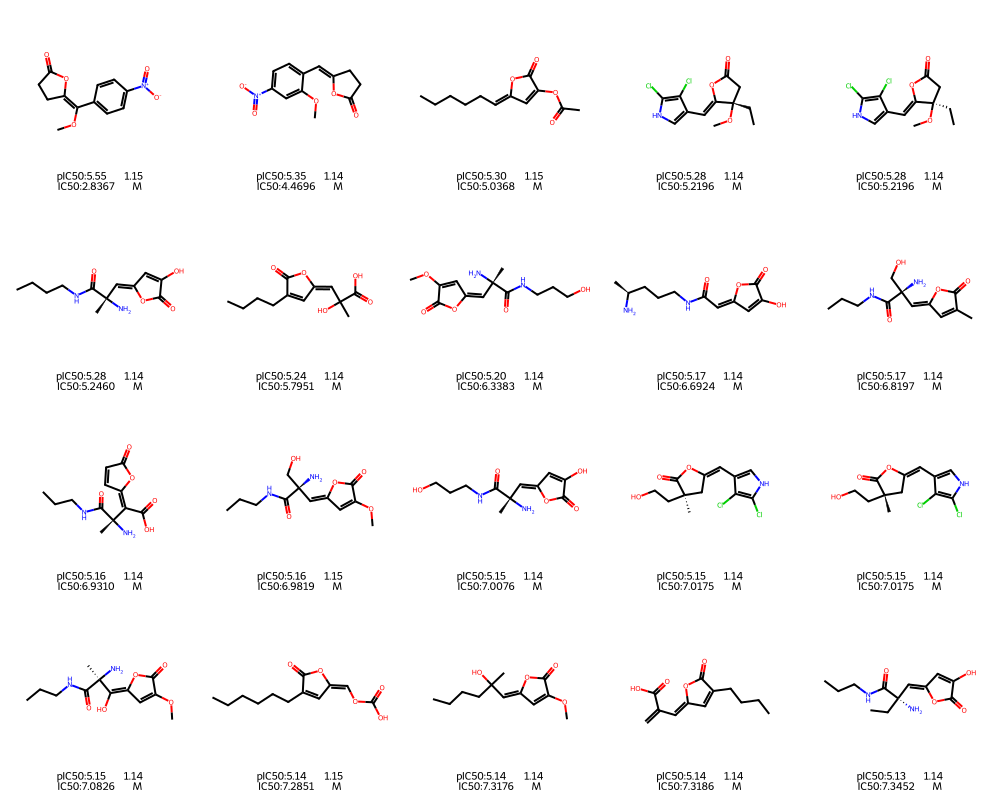

In [28]:
top = generatedCompounds_wARTprediction_topN.head(topN)
mols,legs=[],[]
for _,row in top.iterrows():
    mol=Chem.MolFromSmiles(row["Canonical_SMILES"])
    if mol is None: continue
    ss=row.get("pPotency_std",np.nan)
    label=(f"pIC50:{row['pPotency_prediction']:.2f}±{ss:.2f}\nIC50:{row['IC50 (µM)']:.4f}µM"
           if pd.notna(ss) else f"pIC50:{row['pPotency_prediction']:.2f}\nIC50:{row['IC50 (µM)']:.4f}µM")
    mols.append(mol); legs.append(label)

outPng=os.path.join(resultsDir,f"{target}_generatedCompounds_top{topN}.png")
outSvg=os.path.join(resultsDir,f"{target}_generatedCompounds_top{topN}.svg")
imgPng=Draw.MolsToGridImage(mols,subImgSize=(200,200),molsPerRow=5,legends=legs,useSVG=False,returnPNG=True)
imgSvg=Draw.MolsToGridImage(mols,subImgSize=(200,200),molsPerRow=5,legends=legs,useSVG=True)
with open(outPng,"wb") as fh: fh.write(imgPng.data if hasattr(imgPng,"data") else imgPng)
with open(outSvg,"w")  as fh: fh.write(imgSvg.data if hasattr(imgSvg,"data") else imgSvg)
print("Saved:",outPng); display(imgPng)

In [29]:
mapping = generatedCompounds[["Canonical_SMILES","Starter_Name"]].drop_duplicates("Canonical_SMILES")
generatedCompounds_wARTprediction_topN = generatedCompounds_wARTprediction_topN.merge(mapping,on="Canonical_SMILES",how="left")
generatedCompounds_wARTprediction_topN.to_csv(
    os.path.join(resultsDir,f"{target}_generatedCompounds_top{topN}.csv"),index=False)
generatedCompounds_wARTprediction_topN[["Canonical_SMILES"]].to_csv(
    os.path.join(resultsDir,f"{target}_generatedCompounds_top{topN}_SMILESonly.csv"),index=False)
generatedCompounds_wARTprediction_topN

,Rank,Starter_Name_x,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),Starter_Name_y
0,1,BasidalinPrecursor_starter_01878,O=C1CCC(=Cc2ccc([N+](=O)[O-])cc2)O1,COC(=C1CCC(=O)O1)c1ccc([N+](=O)[O-])cc1,5.547,1.146714,2.836650,BasidalinPrecursor_starter_01878
1,2,BasidalinPrecursor_starter_01878,O=C1CCC(=Cc2ccc([N+](=O)[O-])cc2)O1,COc1cc([N+](=O)[O-])ccc1C=C1CCC(=O)O1,5.350,1.142434,4.469554,BasidalinPrecursor_starter_01878
2,3,BasidalinPrecursor_starter_00394,CCCC=C1C=C(O)C(=O)O1,CCCCCC=C1C=C(OC(C)=O)C(=O)O1,5.298,1.145155,5.036806,BasidalinPrecursor_starter_00394
3,4,BasidalinPrecursor_starter_01332,CC[C@@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@@H]1O,CC[C@]1(OC)CC(=O)OC1=Cc1c[nH]c(Cl)c1Cl,5.282,1.142028,5.219646,BasidalinPrecursor_starter_01332
4,5,BasidalinPrecursor_starter_01291,CC[C@@H]1C(=O)OC(=Cc2c[nH]c(Cl)c2Cl)[C@H]1O,CC[C@@]1(OC)CC(=O)OC1=Cc1c[nH]c(Cl)c1Cl,5.282,1.142028,5.219646,BasidalinPrecursor_starter_01291
5,6,BasidalinPrecursor_starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)[C@H](C)N,CCCCNC(=O)[C@@](C)(N)C=C1C=C(O)C(=O)O1,5.280,1.144237,5.245963,BasidalinPrecursor_starter_02053
6,7,BasidalinPrecursor_starter_00073,CCC=C1C=C(CCCC)C(=O)O1,CCCCC1=CC(=CC(C)(O)C(=O)O)OC1=O,5.237,1.141928,5.795050,BasidalinPrecursor_starter_00073
7,8,BasidalinPrecursor_starter_02007,COC1=CC(=C[C@@H](C)CNC(=O)[C@H](C)N)OC1=O,COC1=CC(=C[C@](C)(N)C(=O)NCCCO)OC1=O,5.198,1.142275,6.338264,BasidalinPrecursor_starter_02007
8,9,BasidalinPrecursor_starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)[C@H](C)N,C[C@H](N)CCCNC(=O)C=C1C=C(O)C(=O)O1,5.174,1.142883,6.692416,BasidalinPrecursor_starter_02053
9,10,BasidalinPrecursor_starter_02044,CC1=CC(=C[C@@H](C)CNC(=O)[C@H](C)N)OC1=O,CCCNC(=O)[C@@](N)(C=C1C=C(C)C(=O)O1)CO,5.166,1.141948,6.819746,BasidalinPrecursor_starter_02044


### ADMET for all generated compounds

Two options are provided. For large compound sets (> 25,000 compounds) `Option A (command line)`
is strongly recommended: it batches predictions, writes a checkpoint after
every batch so a crashed run resumes where it left off, and optionally applies
a Tanimoto diversity filter before prediction.

`Option B (inline)` runs the same `ADMETModel` call synchronously with no
checkpointing. It is only practical for small sets.

The code cell below checks how many compounds are queued and prints an explicit
recommendation. The config YAML is written automatically, so you can go
straight to the terminal command.

#### Option A — command line

```bash
cd Results_{target}/Step4_ADMET
python runADMET.py ADMET_config_DORAnetMol.yaml > admet_DORAnetMol.out
```

Copy `runADMET.py` into `Step4_ADMET/` before running. Outputs:

- `{target}_generatedCompounds_wART_wADMET.csv` — full table with ADMET columns
- `{target}_generatedCompounds_wART_wADMET_checkpoint.csv` — per-batch checkpoint
- `{target}_generatedCompounds_wART_diverseInput.csv` — diversity-filtered input

#### Option B — inline (small sets only)

Set `useInlineADMET = True` in the cell below.

In [30]:
# Step4_ADMET holds the config YAML and the staged input copy.
admetDir = os.path.join(resultsDir, "Step4_ADMET")
os.makedirs(admetDir, exist_ok=True)

# The ART prediction file produced by the previous cell.
artPredFile = os.path.join(resultsDir, f"{target}_allGeneratedCompounds_ARTprediction.csv")

# Copy the ART file under a shorter stem so runADMET.py produces the exact
# output filename {target}_generatedCompounds_wART_wADMET.csv.
admetInputFile = os.path.join(admetDir, f"{target}_generatedCompounds_wART.csv")
shutil.copy2(artPredFile, admetInputFile)

# All runADMET.py outputs land in resultsDir so the final CSV sits alongside
# the other Step 4 tables in Results_Ebola/.
admetOutputFile     = os.path.join(resultsDir, f"{target}_generatedCompounds_wART_wADMET.csv")
admetCheckpointFile = os.path.join(resultsDir, f"{target}_generatedCompounds_wART_wADMET_checkpoint.csv")
admetDiverseFile    = os.path.join(resultsDir, f"{target}_generatedCompounds_wART_diverseInput.csv")

# Count compounds and recommend a route.
nCompounds = len(generatedCompounds_ARTprediction)
CMDLINE_THRESHOLD = 25_000
print(f"Compounds listed for ADMET prediction: {nCompounds:,}")
if nCompounds > CMDLINE_THRESHOLD:
    print(f"  > {CMDLINE_THRESHOLD:,} compounds detected — command line (Option A) is strongly recommended.")
    print("  Inline prediction at this scale is slow and has no fault tolerance.")
else:
    print(f"  <= {CMDLINE_THRESHOLD:,} compounds — either option will work.")

# Write the ADMET config YAML into Step4_ADMET/.
admetConfig = {
    "inputFile":                  admetInputFile,
    "outputDir":                  resultsDir,         # final CSV written to Results_Ebola/
    "SMILES_Column":              "Canonical_SMILES",
    "selectSMILES":               None,
    "batchSize":                  500,
    "saveEveryBatch":             True,
    "resumeFromCheckpoint":       True,
    "deduplicateSmiles":          True,
    "enableDiversityFilter":      True,
    "similarityThreshold":        1.0,
    "fingerprintRadius":          2,
    "fingerprintBits":            2048,
    "diversityChunkSize":         1000,
    "saveDiversityFilteredInput": True,
    "diversityOutputSuffix":      "_diverseInput",
    "useCanonicalFiltering":      True,
    "outputSuffix":               "_wADMET",
}

admetConfigPath = os.path.join(admetDir, "ADMET_config_DORAnetMol.yaml")
with open(admetConfigPath, "w") as h:
    yaml.dump(admetConfig, h, default_flow_style=False, sort_keys=False)

print()
print("Config written to:", admetConfigPath)
print("Input file:       ", admetInputFile)
print("Output file:      ", admetOutputFile)
print()
print("Option A — run from the terminal:")
print(f"  cd {admetDir}")
print("  python runADMET.py ADMET_config_DORAnetMol.yaml > ADMET_DORAnetMol.out")
print()

# ---- Option B: inline ADMET (set True only for small compound sets) ----
useInlineADMET = False

if useInlineADMET:
    generatedCompounds_wART_wADMET = computeAdmet(generatedCompounds_ARTprediction, "Canonical_SMILES")
    generatedCompounds_wART_wADMET = retainEndpoints(
        generatedCompounds_wART_wADMET, ["Starter_Name", "Canonical_SMILES"])
    generatedCompounds_wART_wADMET.to_csv(admetOutputFile, index=False)
    print("Inline ADMET complete. Shape:", generatedCompounds_wART_wADMET.shape)
    print("Saved to:", admetOutputFile)
else:
    # Load the output written by runADMET.py (Option A).
    # Run the command above first, then re-execute this cell.
    if os.path.exists(admetOutputFile):
        generatedCompounds_wART_wADMET = pd.read_csv(admetOutputFile)
        print("Loaded ADMET output:", admetOutputFile)
        print("Shape:", generatedCompounds_wART_wADMET.shape)
    else:
        print("ADMET output not found yet:", admetOutputFile)
        print("Run the Option A command above, then re-execute this cell.")
        generatedCompounds_wART_wADMET = pd.DataFrame()

Compounds listed for ADMET prediction: 642,240
  > 25,000 compounds detected — command line (Option A) is strongly recommended.
  Inline prediction at this scale is slow and has no fault tolerance.

Config written to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/Step4_ADMET/ADMET_config_DORAnetMol.yaml
Input file:        /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/Step4_ADMET/BacillusAnthracis_generatedCompounds_wART.csv
Output file:       /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_generatedCompounds_wART_wADMET.csv

Option A — run from the terminal:
  cd /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/Step4_ADMET
  python runADMET.py ADMET_config_DORAnetMol.yaml > ADMET_DORAnetMol.out

ADMET output not found yet: /mnt/data.ese/nfs/user

In [ ]:
generatedByStarter = {n:s.copy() for n,s in generatedCompounds_wART_wADMET.groupby("Starter_Name")}
print("Starters:", list(generatedByStarter.keys()))

## 4.4 Starter molecules — potency and ADMET

In [ ]:
starterMoleculesDF = pd.DataFrame([{"drugName":k,"Canonical_SMILES":canonicalizeSmiles(v)}
                                       for k,v in StarterMoleculesDict.items()])
starterMoleculesDF_wMACAW     = macawEmbed(starterMoleculesDF,"Canonical_SMILES",macawTransformer)
starterMoleculesDF_wART        = artPredict(starterMoleculesDF_wMACAW,art_macaw,["drugName","Canonical_SMILES"])
starterMoleculesDF_wART_wADMET = computeAdmet(starterMoleculesDF_wART,"Canonical_SMILES")
starterMoleculesDF_wART_wADMET.to_csv(os.path.join(resultsDir,"starterMoleculesDF_wART_wADMET.csv"),index=False)
starterMoleculesDF_wART

## 4.5 Experimental reference potency data

In [ ]:
expRows=[]
for name,entry in ExperimentalPotencyDict.items():
    vals=pd.Series(entry["pPotencyValues"],dtype="float64")
    expRows.append({"drugName":name,"Canonical_SMILES":canonicalizeSmiles(entry["smiles"]),
                    "pPotency_prediction":vals.mean(),"pPotency_std":vals.std(ddof=1)})
experimentalDataDF = pd.DataFrame(expRows)
experimentalDataDF["pPotency_lower_95CI"] = experimentalDataDF["pPotency_prediction"]-1.96*experimentalDataDF["pPotency_std"]
experimentalDataDF["pPotency_upper_95CI"] = experimentalDataDF["pPotency_prediction"]+1.96*experimentalDataDF["pPotency_std"]
experimentalDataDF_wADMET = computeAdmet(experimentalDataDF,"Canonical_SMILES")
experimentalDataDF_wADMET.to_csv(os.path.join(resultsDir,"experimentalDataDF_wADMET.csv"),index=False)
experimentalDataDF

## 4.6 Final scoring and potency-ADMET plots

In [ ]:
toxicityMeta=[
    ("AMES","lowerBetter"),("Carcinogens_Lagunin","lowerBetter"),("ClinTox","lowerBetter"),
    ("DILI","lowerBetter"),("Skin_Reaction","lowerBetter"),("hERG","lowerBetter"),
    ("LD50_Zhu","higherBetter"),("NR-AR-LBD","lowerBetter"),("NR-AR","lowerBetter"),
    ("NR-AhR","lowerBetter"),("NR-Aromatase","lowerBetter"),("NR-ER-LBD","lowerBetter"),
    ("NR-ER","lowerBetter"),("NR-PPAR-gamma","lowerBetter"),("SR-ARE","lowerBetter"),
    ("SR-ATAD5","lowerBetter"),("SR-HSE","lowerBetter"),("SR-MMP","lowerBetter"),
    ("SR-p53","lowerBetter"),
]
admeMeta=[
    ("Bioavailability_Ma","higherBetter"),("HIA_Hou","higherBetter"),
    ("Caco2_Wang","higherBetter"),("PAMPA_NCATS","higherBetter"),
    ("Pgp_Broccatelli","lowerBetter"),("BBB_Martins","lowerBetter"),
    ("CYP1A2_Veith","lowerBetter"),("CYP2C19_Veith","lowerBetter"),
    ("CYP2C9_Veith","lowerBetter"),("CYP2D6_Veith","lowerBetter"),
    ("CYP3A4_Veith","lowerBetter"),("CYP2C9_Substrate_CarbonMangels","lowerBetter"),
    ("CYP2D6_Substrate_CarbonMangels","lowerBetter"),("CYP3A4_Substrate_CarbonMangels","lowerBetter"),
]
toxCols_s  =[x for x,_ in toxicityMeta]; admeCols_s=[x for x,_ in admeMeta]
toxDes_s   =[f"{x}_des" for x in toxCols_s]; admeDes_s=[f"{x}_des_adme" for x in admeCols_s]
keepCols_s = ["drugName","SMILES"]+potencyCols+toxCols_s+admeCols_s

def prepScore(df,lbl):
    df=df.copy()
    if "Canonical_SMILES" in df.columns and "SMILES" not in df.columns:
        df=df.rename(columns={"Canonical_SMILES":"SMILES"})
    if "drugName" not in df.columns:
        df["drugName"]=df.get("Drug_Type",df.get("Starter_Name",np.nan))
    df["datasetLabel"]=lbl; return df

def ensureCols_s(df,cols):
    df=df.copy()
    for c in cols:
        if c not in df.columns: df[c]=np.nan
    return df[cols].copy()

def robIQR(s):
    arr=pd.to_numeric(s,errors="coerce").dropna()
    if len(arr)<5: return np.nan
    return np.subtract(*np.percentile(arr,[75,25]))

def sortedRef(s):
    arr=pd.to_numeric(s,errors="coerce").dropna().to_numpy(float)
    return np.sort(arr[np.isfinite(arr)])

def hBDes(refS,valS):
    ref=sortedRef(refS); val=pd.to_numeric(valS,errors="coerce").to_numpy(float)
    out=np.full(len(val),np.nan); m=np.isfinite(val)
    if len(ref)==0: return pd.Series(out,index=valS.index)
    out[m]=np.clip(np.searchsorted(ref,val[m],"right")/len(ref),0,1)
    return pd.Series(out,index=valS.index)

def lBDes(refS,valS):
    ref=sortedRef(refS); val=pd.to_numeric(valS,errors="coerce").to_numpy(float)
    out=np.full(len(val),np.nan); m=np.isfinite(val)
    if len(ref)==0: return pd.Series(out,index=valS.index)
    out[m]=np.clip(1-np.searchsorted(ref,val[m],"right")/len(ref),0,1)
    return pd.Series(out,index=valS.index)

def wGeoMean(df,cols,ws):
    val=df[cols].to_numpy(float); w=np.asarray(ws,float); out=np.full(val.shape[0],np.nan)
    for i in range(val.shape[0]):
        row=val[i]; m=np.isfinite(row)
        if m.sum()==0: continue
        out[i]=np.exp(np.sum(w[m]*np.log(np.clip(row[m],1e-6,1)))/np.sum(w[m]))
    return pd.Series(out,index=df.index)

def compWeights(refDF,meta,cols):
    corr=refDF[cols].apply(pd.to_numeric,errors="coerce").corr().abs(); rows=[]
    for ep,d in meta:
        iqr=robIQR(refDF[ep]); inf=1/(iqr+1e-6) if pd.notna(iqr) else 1.0
        others=[x for x in cols if x!=ep]
        mc=corr.loc[ep,others].dropna().mean() if (ep in corr.index and others) else np.nan
        uniq=max(1-mc,1e-3) if pd.notna(mc) else 1.0
        rows.append({"endpoint":ep,"direction":d,"rawWeight":inf*uniq})
    wDf=pd.DataFrame(rows); wDf["finalWeight"]=wDf["rawWeight"]/wDf["rawWeight"].sum()
    return wDf

def buildScoredData(refRaw,genDict,exptRaw):
    ref=prepScore(refRaw,"Reference"); expt=prepScore(exptRaw,"Expt")
    genPrepped={k:prepScore(v,"Generated") for k,v in genDict.items()}
    refDF=ensureCols_s(ref,keepCols_s)
    candMap={k:ensureCols_s(v,keepCols_s) for k,v in genPrepped.items()}
    exptDF=ensureCols_s(expt,keepCols_s)
    for c in potencyCols+toxCols_s+admeCols_s:
        refDF[c]=pd.to_numeric(refDF[c],errors="coerce")
        for k in candMap: candMap[k][c]=pd.to_numeric(candMap[k][c],errors="coerce")
        exptDF[c]=pd.to_numeric(exptDF[c],errors="coerce")
    tW=compWeights(refDF,toxicityMeta,toxCols_s)
    aW=compWeights(refDF,admeMeta,admeCols_s)
    def scoreDF(df):
        df=df.copy()
        for ep,d in toxicityMeta:
            df[f"{ep}_des"]=(hBDes if d=="higherBetter" else lBDes)(refDF[ep],df[ep])
        for ep,d in admeMeta:
            df[f"{ep}_des_adme"]=(hBDes if d=="higherBetter" else lBDes)(refDF[ep],df[ep])
        df["PotencyDesRaw"] =hBDes(refDF["pPotency_prediction"],df["pPotency_prediction"])
        df["ToxicitySafety"] =wGeoMean(df,toxDes_s, tW["finalWeight"])
        df["ADMEfeasibility"]=wGeoMean(df,admeDes_s,aW["finalWeight"])
        df["coreToxicityScore"]=1-df["ToxicitySafety"]
        return df
    return refDF,{k:scoreDF(v) for k,v in candMap.items()},scoreDF(exptDF)

def admeToSize(v,sMin=10,sMax=120): return sMin+np.clip(v,0,1)*(sMax-sMin)

def orderedLegend(ax):
    h,l=ax.get_legend_handles_labels(); uniq=dict(zip(l,h))
    deriv=[(k,v) for k,v in uniq.items() if "deriv" in k.lower()]
    pred =[(k,v) for k,v in uniq.items() if "(predicted)" in k.lower()]
    exptL=[(k,v) for k,v in uniq.items() if "(expt.)" in k.lower()]
    nr=max(len(deriv),len(pred),len(exptL))
    blank=Patch(color="none",label="")
    def pad(p): return p+[("",blank)]*(nr-len(p))
    all_=pad(deriv)+pad(pred)+pad(exptL)
    return [e[1] for e in all_],[e[0] for e in all_]

In [ ]:
referenceAndStarterDF = (pd.concat([referenceDrugsDF_wART_wADMET,starterMoleculesDF_wART_wADMET],ignore_index=True)
    .drop_duplicates(subset=["Canonical_SMILES"]).reset_index(drop=True))

generatedDictRaw = {f"{n} derivatives":df.copy() for n,df in generatedByStarter.items()}
generatedDictRaw["Individual"] = referenceAndStarterDF.copy()

allStarterNames  = sorted(generatedByStarter.keys())
allRefNames      = list(ReferenceDrugs.keys())
candidateOrder   = allStarterNames+[r for r in allRefNames if r not in allStarterNames]
sourceToBase     = {f"{n} derivatives":n for n in allStarterNames}

tabColors=plt.cm.tab10.colors
for i,n in enumerate(allStarterNames):
    if n not in baseColorMap: baseColorMap[n]=matplotlib.colors.to_hex(tabColors[i%len(tabColors)])

_,scoredCandMap,exptScoreDF = buildScoredData(fdaAntiviralDF_wART_wADMET,generatedDictRaw,experimentalDataDF_wADMET)
print("Scored groups:", list(scoredCandMap.keys()))

### Plot 1: pPotency strip plot

In [ ]:
ypos={n:i for i,n in enumerate(candidateOrder)}; rng=np.random.default_rng(123)
fig,ax=plt.subplots(figsize=(10.5,7.5))
for srcName,srcDF in scoredCandMap.items():
    if srcName=="Individual": continue
    pDf=srcDF.dropna(subset=["pPotency_prediction"]).copy()
    bN=sourceToBase.get(srcName); y0=ypos.get(bN)
    if y0 is None: continue
    yj=y0+rng.normal(0,0.06,len(pDf))
    ax.scatter(pDf["pPotency_prediction"],yj,s=14,alpha=0.35,
               color=baseColorMap.get(bN,"gray"),label=f"{bN} derivatives")
if "Individual" in scoredCandMap:
    iDF=(scoredCandMap["Individual"].dropna(subset=["drugName","pPotency_prediction"])
         .drop_duplicates(subset=["drugName","SMILES"]).copy())
    for _,row in iDF.iterrows():
        dname=row["drugName"]
        if dname not in ypos: continue
        ax.scatter(row["pPotency_prediction"],ypos[dname],marker="o",s=150,
                   color=baseColorMap.get(dname,"black"),edgecolors="black",
                   linewidths=0.95,alpha=0.98,label=f"{dname} (predicted)",zorder=6)
eDf=(exptScoreDF.dropna(subset=["drugName","pPotency_prediction"]).drop_duplicates(subset=["drugName","SMILES"]).copy())
for _,row in eDf.iterrows():
    dname=row["drugName"]
    if dname not in ypos: continue
    yy=ypos[dname]+0.12; c=baseColorMap.get(dname,"black")
    ax.scatter(row["pPotency_prediction"],yy,marker="*",s=190,color=c,edgecolors="black",
               linewidths=0.9,alpha=0.98,label=f"{dname} (expt.)",zorder=7)
    if pd.notna(row.get("pPotency_std",np.nan)):
        ax.errorbar(row["pPotency_prediction"],yy,xerr=float(row["pPotency_std"]),
                    fmt="none",ecolor=c,elinewidth=1.0,capsize=2,alpha=0.95,zorder=6)
ax.set_xlabel("pPotency prediction"); ax.set_ylabel("Drug candidates")
ax.set_yticks(range(len(candidateOrder))); ax.set_yticklabels(candidateOrder)
ax.invert_yaxis(); ax.yaxis.grid(False)
hh,ll=orderedLegend(ax)
ax.legend(hh,ll,loc="lower center",bbox_to_anchor=(0.5,1.02),ncol=3,frameon=True,prop=tnr)
plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig(os.path.join(resultsDir,f"{target}_pPotencyOnly.svg"),format="svg",dpi=600)
plt.savefig(os.path.join(resultsDir,f"{target}_pPotencyOnly.png"),format="png",dpi=600)
plt.show()

### Plot 2: pPotency vs. core toxicity

In [ ]:
fig,ax=plt.subplots(figsize=(9.5,7.5))
for srcName,srcDF in scoredCandMap.items():
    if srcName=="Individual": continue
    pDf=srcDF.dropna(subset=["pPotency_prediction","coreToxicityScore"]).copy()
    bN=sourceToBase.get(srcName)
    ax.scatter(pDf["pPotency_prediction"],pDf["coreToxicityScore"],s=14,alpha=0.35,
               color=baseColorMap.get(bN,"gray"),label=f"{bN} derivatives")
if "Individual" in scoredCandMap:
    iDF=(scoredCandMap["Individual"].dropna(subset=["drugName","pPotency_prediction","coreToxicityScore"])
         .drop_duplicates(subset=["drugName","SMILES"]).copy())
    for _,row in iDF.iterrows():
        dname=row["drugName"]
        ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],marker="o",s=150,
                   color=baseColorMap.get(dname,"black"),edgecolors="black",
                   linewidths=0.95,alpha=0.98,label=f"{dname} (predicted)",zorder=6)
for _,row in (exptScoreDF.dropna(subset=["drugName","pPotency_prediction","coreToxicityScore"])
              .drop_duplicates(subset=["drugName","SMILES"]).iterrows()):
    dname=row["drugName"]; c=baseColorMap.get(dname,"black")
    ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],marker="*",s=190,color=c,
               edgecolors="black",linewidths=0.9,alpha=0.98,label=f"{dname} (expt.)",zorder=7)
    if pd.notna(row.get("pPotency_std",np.nan)):
        ax.errorbar(row["pPotency_prediction"],row["coreToxicityScore"],
                    xerr=float(row["pPotency_std"]),fmt="none",ecolor=c,elinewidth=1.0,capsize=2,alpha=0.95,zorder=6)
ax.set_xlabel("pPotency prediction"); ax.set_ylabel("Core Toxicity Score")
ax.set_ylim(0,1.05); ax.grid(False)

# Build legend in explicit column order: derivatives | predicted | expt.
# candidateOrder drives within-column ordering so the layout matches the target figure.
allHandles, allLabels = ax.get_legend_handles_labels()
labelToHandle = dict(zip(allLabels, allHandles))
blank = Patch(color="none", label="")

derivLabels = [f"{n} derivatives" for n in candidateOrder if f"{n} derivatives" in labelToHandle]
predLabels  = [f"{n} (predicted)" for n in candidateOrder if f"{n} (predicted)" in labelToHandle]
exptLabels  = [f"{n} (expt.)"     for n in candidateOrder if f"{n} (expt.)"     in labelToHandle]

nRows = max(len(derivLabels), len(predLabels), len(exptLabels))
def padCol(lst): return lst + [""] * (nRows - len(lst))

orderedLabels  = padCol(derivLabels) + padCol(predLabels) + padCol(exptLabels)
orderedHandles = [labelToHandle.get(l, blank) for l in orderedLabels]

ax.legend(orderedHandles, orderedLabels, loc="lower center", bbox_to_anchor=(0.5,1.02),
          ncol=3, frameon=True, prop=tnr)

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity.svg"),format="svg",dpi=600)
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity.png"),format="png",dpi=600)
plt.show()

### Plot 3: pPotency vs. core toxicity with ADME bubble size

In [ ]:
fig,ax=plt.subplots(figsize=(9.5,7.5))
for srcName,srcDF in scoredCandMap.items():
    if srcName=="Individual": continue
    pDf=srcDF.dropna(subset=["pPotency_prediction","coreToxicityScore","ADMEfeasibility"]).copy()
    bN=sourceToBase.get(srcName)
    ax.scatter(pDf["pPotency_prediction"],pDf["coreToxicityScore"],
               s=admeToSize(pDf["ADMEfeasibility"].values),alpha=0.35,
               color=baseColorMap.get(bN,"gray"),label=f"{bN} derivatives")
if "Individual" in scoredCandMap:
    iDF=(scoredCandMap["Individual"].dropna(subset=["drugName","pPotency_prediction","coreToxicityScore","ADMEfeasibility"])
         .drop_duplicates(subset=["drugName","SMILES"]).copy())
    for _,row in iDF.iterrows():
        dname=row["drugName"]
        ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],marker="o",
                   s=admeToSize(float(row["ADMEfeasibility"])),
                   color=baseColorMap.get(dname,"black"),edgecolors="black",
                   linewidths=0.95,alpha=0.98,label=f"{dname} (predicted)",zorder=6)
for _,row in (exptScoreDF.dropna(subset=["drugName","pPotency_prediction","coreToxicityScore","ADMEfeasibility"])
              .drop_duplicates(subset=["drugName","SMILES"]).iterrows()):
    dname=row["drugName"]; c=baseColorMap.get(dname,"black")
    ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],marker="*",
               s=admeToSize(float(row["ADMEfeasibility"])),color=c,edgecolors="black",
               linewidths=0.9,alpha=0.98,label=f"{dname} (expt.)",zorder=7)
    if pd.notna(row.get("pPotency_std",np.nan)):
        ax.errorbar(row["pPotency_prediction"],row["coreToxicityScore"],
                    xerr=float(row["pPotency_std"]),fmt="none",ecolor=c,elinewidth=1.0,capsize=2,alpha=0.95,zorder=6)
admeLeg=ax.legend(handles=[mlines.Line2D([],[],linestyle="none",marker="o",color="gray",alpha=0.6,
    markersize=np.sqrt(admeToSize(v)),label=f"ADME={v:.2f}") for v in [0.25,0.50,0.75,1.00]],
    title="ADME feasibility",loc="lower right",frameon=True,prop=tnr,title_fontproperties=tnr)
ax.add_artist(admeLeg)
ax.set_xlabel("pPotency prediction"); ax.set_ylabel("Core Toxicity Score")
ax.set_ylim(0,1.05); ax.grid(False)
hh,ll=orderedLegend(ax)
ax.legend(hh,ll,loc="lower center",bbox_to_anchor=(0.5,1.02),ncol=3,frameon=True,prop=tnr)
plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity_ADME.svg"),format="svg",dpi=600)
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity_ADME.png"),format="png",dpi=600)
plt.show()

### Plot 4: per-starter subplot grid with ADME marker shapes

In [ ]:
admeBinsDef=[(0.00,0.25,"P","red","ADME 0.00-0.25 (poor)"),
               (0.25,0.50,"s","green","ADME 0.25-0.50"),
               (0.50,0.75,"p","blue","ADME 0.50-0.75"),
               (0.75,1.00,"D","magenta","ADME 0.75-1.00 (high)")]

def getAdmeBin(v):
    for lo,hi,mk,col,_ in admeBinsDef:
        if lo<=float(v)<=hi: return mk,col
    return "P","red"

familyPlotOrder=[s for s in sourceToBase.keys() if s in scoredCandMap]
nF=len(familyPlotOrder); nC=2; nR=-(-nF//nC)

indivAll=pd.DataFrame()
if "Individual" in scoredCandMap:
    indivAll=(scoredCandMap["Individual"]
              .dropna(subset=["drugName","pPotency_prediction","coreToxicityScore","ADMEfeasibility"])
              .drop_duplicates(subset=["drugName","SMILES"]).copy())
exptAll=(exptScoreDF.dropna(subset=["drugName","pPotency_prediction","coreToxicityScore","ADMEfeasibility"])
         .drop_duplicates(subset=["drugName","SMILES"]).copy())

fig,axes=plt.subplots(nR,nC,figsize=(11,nR*4.8))
axes=axes.flatten() if nR*nC>1 else [axes]

for i,srcName in enumerate(familyPlotOrder):
    ax=axes[i]; bN=sourceToBase[srcName]
    pDf=scoredCandMap[srcName].dropna(subset=["pPotency_prediction","coreToxicityScore","ADMEfeasibility"]).copy()
    for lo,hi,mk,col,_ in admeBinsDef:
        mask=(pDf["ADMEfeasibility"]>=lo)&(pDf["ADMEfeasibility"]<=hi)
        if mask.any(): ax.scatter(pDf.loc[mask,"pPotency_prediction"],pDf.loc[mask,"coreToxicityScore"],
                                   s=18,marker=mk,alpha=0.45,color=col,edgecolors="none")
    for _,row in indivAll[indivAll["drugName"]==bN].iterrows():
        mk,col=getAdmeBin(row["ADMEfeasibility"])
        ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],
                   marker=mk,s=140,color=col,edgecolors="black",linewidths=0.95,alpha=0.98,zorder=6)
    for _,row in exptAll[exptAll["drugName"]==bN].iterrows():
        mk,col=getAdmeBin(row["ADMEfeasibility"])
        ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],
                   marker=mk,s=220,color=col,edgecolors="black",linewidths=1.1,alpha=0.98,zorder=7)
        if pd.notna(row.get("pPotency_std",np.nan)):
            ax.errorbar(row["pPotency_prediction"],row["coreToxicityScore"],
                        xerr=float(row["pPotency_std"]),fmt="none",ecolor=col,elinewidth=1.0,capsize=2,alpha=0.95,zorder=6)
    ax.set_title(bN); ax.set_xlabel("pPotency prediction"); ax.set_ylabel("Core Toxicity Score")
    ax.set_ylim(0,1.05)

for j in range(nF,len(axes)): axes[j].set_visible(False)

fig.legend(handles=[
    mlines.Line2D([],[],linestyle="none",marker=mk,color=col,markersize=8,
                  markeredgecolor="black",alpha=0.9,label=lbl)
    for _,_,mk,col,lbl in admeBinsDef]+[
    mlines.Line2D([],[],linestyle="none",marker="o",color="gray",markersize=7,markeredgecolor="black",label="Individual predicted"),
    mlines.Line2D([],[],linestyle="none",marker="o",color="gray",markersize=10,markeredgecolor="black",label="Individual experimental"),
],loc="lower center",bbox_to_anchor=(0.5,0.0),ncol=3,frameon=True,prop=tnr,
  title="ADME feasibility - marker shape and color",title_fontproperties=tnr)
plt.tight_layout(rect=[0,0.12,1,1])
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity_ADME_perStarter.svg"),format="svg",dpi=600)
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity_ADME_perStarter.png"),format="png",dpi=600)
plt.show()